**LIESSE Nathan & SALIOU Yves-Marie**

**Github** : https://github.com/yvesmarix/PROJET-QRT-ELEC/tree/main

# Table des matières


# 1) Sujet

Le sujet provient de QRT et se nomme : "Comment expliquer le prix de l'électricité ? "

## 1.1) Contexte

L'objectif du challenge est de modéliser les variations journalières du prix des contrats futures d'électricité pour la France et l'Allemagne à partir de variables explicatives météorologiques, énergétiques et commerciales.

Il s'agit d'un problème de régression supervisée dans lequel la variable cible correspond à la variation du prix de l'électricité à court terme (24h). L'objectif principal est d'expliquer les variations relatives du prix plutôt qu'en estimer la valeur. Cela est reflété par la métrique de corrélation de Spearman qui mesure la capacité du modèle à correctement ordonner les observations. Les données incluent notamment des variations journalières du prix des matières premières (Gaz, Charbon et futures sur les émissions carbone), des mesures météorologiques (température, pluie et vent), des mesures de productions (gaz naturel, charbon, hydrolique, nucléaire, photovoltaïque, éolienne, lignite) ainsi que des mesures d'utilisation électrique (consommation, exports, échanges entre la France et l'Allemagne).

Contexte du marché de l'électricité : 
Le marché de l'électricité est un marché où l'actif est physique et non stockable. Son prix est fixé par le coût marginal de la dernière unité de production (merit order). La France et l'Allemagne au dela que leur proximité et de leur frontière en commun, importent et exportent de l'électricité entre leur deux pays. En effet, ayant des mix énergétiques bien différents (plutôt nucléaire pour la France et renouvelable pour l'Allemagne), des arbitrages peuvent avoir lieu entre ces deux pays.

Lors d'évènement météorologique où le vent et le soleil sont absents, l'Allemagne doit allumer leurs centrales à charbon. Afin de palier à cette méthode de production d'électricité qui coûte cher, l'Allemagne peut acheter de l'électricité produite par les centrales française. Nous voyons donc tout l'intérêt d'étudier ces deux pays, lié dans la production d'électricité.

## 1.2) Description des données

**Variables explicatives**:
Les données d'entrée possèdent 35 colonnes :

- ID : Identifiant d'indexe unique, associé à un jour (DAY_ID) et un pays (COUNTRY),
- DAY_ID : Identifiant du jour - les dates ont été annonymisées en préservant la structure des données,
- COUNTRY : Identifiant du pays - DE = Allemagne, FR = France,

et composées ensuite de variations journalières du prix de matières premières,
- GAS_RET : Gaz en Europe,
- COAL_RET : Charbon en Europe,
- CARBON_RET : Futures sur les emissions carbone,

de mesures météorologiques (journalières, dans le pays x),
- x_TEMP : Temperature,
- x_RAIN : Pluie,
- x_WIND : Vent,

de mesures de productions d'energie (journalière, dans le pays x),
- x_GAS : Gaz naturel,
- x_COAL : Charbon,
- x_HYDRO : Hydrolique,
- x_NUCLEAR : Nucléaire,
- x_SOLAR : Photovoltaïque,
- x_WINDPOW : Eolienne,
- x_LIGNITE : Lignite (que pour l'Allemagne),

et de mesures d'utilisation électrique (journalières, dans le pays x),
- x_CONSUMPTON : Electricité totale consommée,
- x_RESIDUAL_LOAD : Electricité consommée après utilisation des énergies renouvelables,
- x_NET_IMPORT: Electricité importée depuis l'Europe,
- x_NET_EXPORT: Electricité exportée vers l'Europe,
- DE_FR_EXCHANGE: Electricité échangée entre Allemagne et France,
- FR_DE_EXCHANGE: Electricité échangée entre France et Allemagne.

**Variable cible**
Les données en sortie se composent de deux colonnes :
- ID : Identifiant unique - le même que celui des données d'entrée,
- TARGET : Variation journalière du prix de futures d'électricité (maturité 24h).


## 1.3) Description du benchmark

# 2) Problématique

# 3) Préparation des données

## 3.1) Import des bibliothèques

In [1]:
#!pip install -r requirements.txt

In [31]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr
from sklearn.cluster import KMeans
import sklearn as sk
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.kernel_ridge import KernelRidge
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet,
    RidgeCV,
    LassoCV,
    ElasticNetCV,
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import make_scorer, silhouette_score
from sklearn.model_selection import GroupKFold, cross_val_score, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import PolynomialFeatures, QuantileTransformer, StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.mixture import GaussianMixture

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import optuna
import warnings
warnings.filterwarnings("ignore")

import os
os.environ["PYTHONWARNINGS"] = "ignore"


## 3.2) Import des données

In [3]:
# data set entrainement
possible_paths = [
    Path("/Users/yves-mariesaliou/Documents/Cours/M2 IEF 272/MACHINE LEARNING/PROJET QRT ELEC"),
    Path("/Users/liessenathan/Desktop/M2/ML/PROJET-QRT-ELEC")
]
path = next((p for p in possible_paths if p.exists()), None)
path = str(path)

x_train = pd.read_csv(os.path.join(path, "X_train_NHkHMNU.csv")).sort_values(by=["COUNTRY", "DAY_ID"])
y_train = pd.read_csv(os.path.join(path, "y_train_ZAN5mwg.csv"))

# ensemble de test
x_test = pd.read_csv(os.path.join(path, "X_test_final.csv"))
y_test = pd.read_csv(os.path.join(path, "y_test_random_final.csv"))

### Vérification des tailles des fichiers

In [4]:
display(x_train.shape)

(1494, 35)

### Vérification des types des données

In [5]:
display(x_train.dtypes)


ID                    int64
DAY_ID                int64
COUNTRY              object
DE_CONSUMPTION      float64
FR_CONSUMPTION      float64
DE_FR_EXCHANGE      float64
FR_DE_EXCHANGE      float64
DE_NET_EXPORT       float64
FR_NET_EXPORT       float64
DE_NET_IMPORT       float64
FR_NET_IMPORT       float64
DE_GAS              float64
FR_GAS              float64
DE_COAL             float64
FR_COAL             float64
DE_HYDRO            float64
FR_HYDRO            float64
DE_NUCLEAR          float64
FR_NUCLEAR          float64
DE_SOLAR            float64
FR_SOLAR            float64
DE_WINDPOW          float64
FR_WINDPOW          float64
DE_LIGNITE          float64
DE_RESIDUAL_LOAD    float64
FR_RESIDUAL_LOAD    float64
DE_RAIN             float64
FR_RAIN             float64
DE_WIND             float64
FR_WIND             float64
DE_TEMP             float64
FR_TEMP             float64
GAS_RET             float64
COAL_RET            float64
CARBON_RET          float64
dtype: object

## 3.3) Exploration des données

### Informations sur notre dataset

In [6]:
#Chevauchement temporel entre le train et le test
print("Train DAY_ID :", x_train['DAY_ID'].min(), "→", x_train['DAY_ID'].max())
print("Test  DAY_ID :", x_test['DAY_ID'].min(), "→", x_test['DAY_ID'].max())
print("Jours communs :", set(x_train['DAY_ID']) & set(x_test['DAY_ID']))

# Répartition des pays
print("\nTrain countries :", x_train['COUNTRY'].value_counts().to_dict())
print("Test  countries :", x_test['COUNTRY'].value_counts().to_dict())

print("\nPourcentage France (train):", round((x_train['COUNTRY'] == "FR").mean(),2),
      "vs Allemagne", round((x_train['COUNTRY'] == "DE").mean(),2))

print("Pourcentage France (test):", round((x_test['COUNTRY'] == "FR").mean(),2),
      "vs Allemagne", round((x_test['COUNTRY'] == "DE").mean(), 2))
      
# Combien d'observations par (DAY_ID, COUNTRY) ?
print("\nDoublons (DAY_ID, COUNTRY) train :", 
      x_train.duplicated(subset=['DAY_ID', 'COUNTRY']).sum())

Train DAY_ID : 0 → 1215
Test  DAY_ID : 4 → 1214
Jours communs : set()

Train countries : {'FR': 851, 'DE': 643}
Test  countries : {'FR': 365, 'DE': 289}

Pourcentage France (train): 0.57 vs Allemagne 0.43
Pourcentage France (test): 0.56 vs Allemagne 0.44

Doublons (DAY_ID, COUNTRY) train : 0


Nous remarquons qu'il n'y a aucun jour en commun entre le x_train et le x_test. Cependant, nous remarquons que le x_test est constitué en piochant et retirant des jours de la série du x_train.

De plus, nous remarquons que le pays France est sureprésenté dans l'échantillon de train (851 contre 643). Cela correspond à 57% pour la France et 43% pour l'Allemagne. Cette proportion est respectée pour le x_test.

Les jours sont donc disjoints mais entrelacés : ce n'est pas un split temporel pur mais un split aléatoire. Les jours ont été tirés au hasard et répartis entre train et test, sur la même période globale.

### Informations sur nos features

In [7]:
x_train[[col for col in x_train.columns if "ID" not in col]].describe()
# on a donc 30 variables explicatives disponibles pour notre Y

,DE_CONSUMPTION,FR_CONSUMPTION,DE_FR_EXCHANGE,FR_DE_EXCHANGE,DE_NET_EXPORT,FR_NET_EXPORT,DE_NET_IMPORT,FR_NET_IMPORT,DE_GAS,FR_GAS,...,DE_LIGNITE,DE_RAIN,FR_RAIN,DE_WIND,FR_WIND,DE_TEMP,FR_TEMP,GAS_RET,COAL_RET,CARBON_RET
count,1494.000000,1494.000000,1469.000000,1469.000000,1370.000000,1424.000000,1370.000000,1424.000000,1494.000000,1494.000000,...,1494.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1494.000000,1494.000000,1494.000000
mean,0.427442,-0.020032,-0.145508,0.145508,-0.256332,-0.072643,0.256332,0.072643,0.780699,0.395019,...,-0.298856,-0.037831,0.019357,0.109480,0.123099,0.009451,0.008404,0.058126,0.061724,0.080510
std,0.673412,0.918995,0.970226,0.970226,0.957443,1.075830,0.957443,1.075830,0.850190,0.906500,...,0.851339,0.984233,1.051781,1.056243,1.054692,0.972394,1.003356,1.097768,1.033853,1.098624
min,-2.265563,-1.462350,-2.856874,-2.634831,-2.464849,-2.825331,-2.279619,-1.951516,-1.117260,-1.317350,...,-2.879041,-2.128531,-1.726420,-1.880419,-1.895319,-4.549638,-5.787097,-5.349463,-5.706442,-4.281790
25%,-0.037421,-0.716771,-0.875213,-0.638867,-0.977214,-0.851500,-0.452252,-0.794843,0.134947,-0.205078,...,-0.787239,-0.642117,-0.503927,-0.652135,-0.672614,-0.618259,-0.647948,-0.624238,-0.458038,-0.522968
50%,0.357061,-0.394166,-0.164287,0.164287,-0.306899,0.099455,0.306899,-0.099455,0.740006,0.256780,...,-0.188300,-0.274901,-0.228147,-0.261571,-0.229031,-0.026306,-0.020889,0.008493,0.063312,0.054056
75%,0.922057,0.650533,0.638867,0.875213,0.452252,0.794843,0.977214,0.851500,1.399461,1.090646,...,0.273510,0.335237,0.154351,0.635050,0.824781,0.651832,0.699131,0.676415,0.641446,0.599094
max,2.033851,3.300640,2.634831,2.856874,2.279619,1.951516,2.464849,2.825331,3.118082,2.372570,...,1.586885,7.756118,9.473201,5.085624,4.965028,2.858758,2.817239,5.674778,3.746576,5.471818


In [8]:
print(x_train.iloc[:, 3:].min().min())
print(x_train.iloc[:, 3:].max().max())

-5.7870971504133175
9.473200582383296


Nos features correspondent à des variations journalières. Les plus basses variations vont jusque -5.8 et les plus hautes jusque 9.5.

### Variable TARGET Visualisation

<Axes: title={'center': 'Return Prix Electricité DE'}, xlabel='DAY_ID'>

<Axes: title={'center': 'Return Prix Electricité FR'}, xlabel='DAY_ID'>

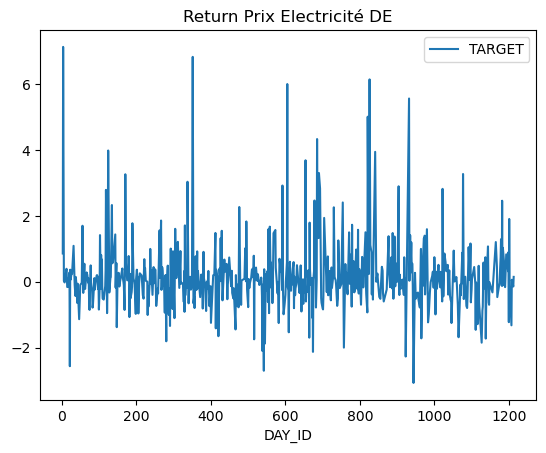

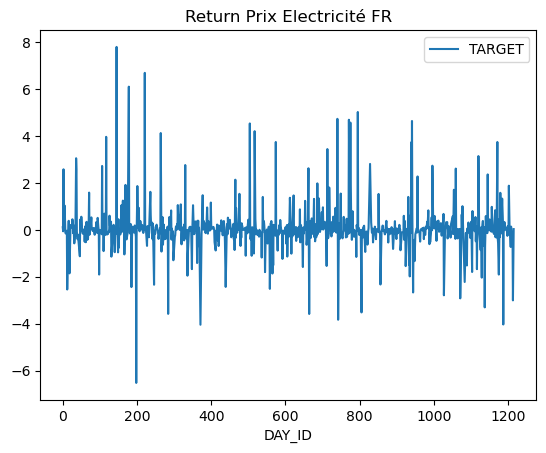

In [9]:
for country in x_train.COUNTRY.unique():
    display(x_train.query(f"COUNTRY == '{country}'")
            .merge(y_train).sort_values(by="DAY_ID")
            .plot(x="DAY_ID", y="TARGET", title=f"Return Prix Electricité {country}"))

# 4) Traitement et création de nouvelles features

## 4.1) Gestion des valeurs manquantes

In [10]:
display(x_train.isna().sum().sort_values(ascending=False))

DE_NET_EXPORT       124
DE_NET_IMPORT       124
DE_RAIN              94
FR_TEMP              94
DE_TEMP              94
FR_WIND              94
DE_WIND              94
FR_RAIN              94
FR_NET_IMPORT        70
FR_NET_EXPORT        70
DE_FR_EXCHANGE       25
FR_DE_EXCHANGE       25
DE_LIGNITE            0
DE_RESIDUAL_LOAD      0
FR_RESIDUAL_LOAD      0
ID                    0
DE_WINDPOW            0
GAS_RET               0
COAL_RET              0
FR_WINDPOW            0
DE_NUCLEAR            0
FR_SOLAR              0
DE_SOLAR              0
FR_NUCLEAR            0
DAY_ID                0
FR_HYDRO              0
DE_HYDRO              0
FR_COAL               0
DE_COAL               0
FR_GAS                0
DE_GAS                0
FR_CONSUMPTION        0
DE_CONSUMPTION        0
COUNTRY               0
CARBON_RET            0
dtype: int64

### 4.1.1) Gestion flux

Logiquement on a :
- DE_FR_EXCHANGE = - FR_DE_EXCHANGE
- DE_NET_EXPORT = - DE_NET_IMPORT
- FR_NET_EXPORT = - FR_NET_IMPORT

In [11]:
flow_pairs = [
    ("DE_FR_EXCHANGE", "FR_DE_EXCHANGE"),
    ("DE_NET_EXPORT", "DE_NET_IMPORT"),
    ("FR_NET_EXPORT", "FR_NET_IMPORT"),
    ]


x_train = x_train.sort_values("DAY_ID")

flux_cols = [c for pair in flow_pairs for c in pair]

display(x_train[["DAY_ID", "COUNTRY"] + flux_cols])

,DAY_ID,COUNTRY,DE_FR_EXCHANGE,FR_DE_EXCHANGE,DE_NET_EXPORT,DE_NET_IMPORT,FR_NET_EXPORT,FR_NET_IMPORT
742,0,FR,-0.079296,0.079296,NaN,NaN,0.650577,-0.650577
1211,1,FR,0.331356,-0.331356,0.405549,-0.405549,0.778627,-0.778627
1408,2,FR,-1.102015,1.102015,-1.080403,1.080403,0.256736,-0.256736
1468,2,DE,-1.102015,1.102015,-1.080403,1.080403,0.256736,-0.256736
680,3,DE,-1.051716,1.051716,-1.881881,1.881881,-0.612133,0.612133
...,...,...,...,...,...,...,...,...
986,1212,DE,-0.270515,0.270515,-0.137917,0.137917,-0.789824,0.789824
1007,1212,FR,-0.270515,0.270515,-0.137917,0.137917,-0.789824,0.789824
1465,1213,DE,-0.456126,0.456126,0.333142,-0.333142,-0.069222,0.069222
873,1213,FR,-0.456126,0.456126,0.333142,-0.333142,-0.069222,0.069222


### 4.1.2) Gestion NaN Value

#### Median

In [12]:
def apply_median_completion(df, medians, columns):
    df_filled = df.copy()

    for col in columns:
        df_filled[col] = df_filled[col].fillna(
            df_filled["COUNTRY"].map(medians[col])
        )
    return df_filled

# columns with NaN in train
columns_to_fill = x_train.columns[x_train.isna().any()]

# compute medians ONLY from train
train_medians = x_train.groupby("COUNTRY")[columns_to_fill].median()

# fill both datasets using train medians
x_train_median = apply_median_completion(x_train, train_medians, columns_to_fill)
x_test_median = apply_median_completion(x_test, train_medians, columns_to_fill)

## 4.2) Ajout de nouvelles features

Le prix de l'électricité spot (et donc sa variation journalière, qui est ta cible) est déterminé par le coût marginal de production : à chaque instant, on empile les centrales par ordre de coût croissant, et le prix est fixé par la dernière centrale appelée pour satisfaire la demande. Cette logique s'appelle le merit order.

Conséquences directes :

* Plus la demande résiduelle (consommation moins renouvelables, qui sont quasi-gratuites) est élevée, * plus on appelle des centrales chères → prix élevé.
* Plus le coût des combustibles fossiles (gaz, charbon) et du carbone est élevé, plus les centrales marginales coûtent cher → prix élevé.
* Les échanges transfrontaliers redistribuent ces effets entre marchés couplés.

In [13]:
# cible alignée sur ID
x_train_median.sort_values(["COUNTRY", "DAY_ID"], inplace=True)
y_train_clean = y_train.set_index("ID").loc[x_train_median["ID"], "TARGET"]


#### Clippage des rendements aux quantiles

In [14]:
# Clipping des rendements aux quantiles 1% / 99% (calcul sur train, appliqué aux deux)
ret_cols = ['GAS_RET', 'COAL_RET', 'CARBON_RET']
lower = x_train_median[ret_cols].quantile(0.01)
upper = x_train_median[ret_cols].quantile(0.99)

x_train_median[ret_cols] = x_train_median[ret_cols].clip(lower=lower, upper=upper, axis=1)
x_test_median[ret_cols]  = x_test_median[ret_cols].clip(lower=lower, upper=upper, axis=1)

### Ajout des features linéaires

In [15]:
def add_cross_border_flows(df):
    """Échanges transfrontaliers nets entre DE et FR."""
    # Flux net DE→FR (positif = DE exporte vers FR)
    df['NET_FLOW_DE_TO_FR'] = df['DE_FR_EXCHANGE'] - df['FR_DE_EXCHANGE']
    df['DE_NET_BALANCE']    = df['DE_NET_EXPORT']  - df['DE_NET_IMPORT']
    df['FR_NET_BALANCE']    = df['FR_NET_EXPORT']  - df['FR_NET_IMPORT']
    df['DE_TRADE_BALANCE']  = df['DE_NET_EXPORT']  - df['DE_NET_IMPORT']
    df['FR_TRADE_BALANCE']  = df['FR_NET_EXPORT']  - df['FR_NET_IMPORT']
    return df


def add_marginal_cost_features(df):
    """Coût marginal de production (Merit Order)."""
    # Coût effectif des centrales gaz (coût gaz + taxe carbone)
    df['GAS_CARBON_COST']  = df['GAS_RET']  + df['CARBON_RET']
    # Coût effectif des centrales charbon
    df["COAL_CARBON_COST"] = df['COAL_RET'] + df['CARBON_RET']
    # Index composite du coût fossile (proxy du prix marginal)
    df["FOSSIL_COST_INDEX"] = 0.5 * df["GAS_CARBON_COST"] + 0.5 * df["COAL_CARBON_COST"]
    # Interaction gaz × carbone : signal fort (corr=+0.10 avec TARGET)
    df["GAS_x_CARBON"] = df["GAS_RET"] * df["CARBON_RET"]
    return df


def add_residual_demand_features(df):
    """Demande résiduelle + interactions météo × production par pays."""
    for country in ["DE", "FR"]:
        renewable   = df[f"{country}_SOLAR"] + df[f"{country}_WINDPOW"] + df[f"{country}_HYDRO"]
        consumption = df[f"{country}_CONSUMPTION"]

        # Production totale ENR
        df[f"{country}_RENEWABLE_PROD"]        = renewable
        # Taux de pénétration ENR
        df[f"{country}_RENEWABLE_PENETRATION"] = renewable / consumption
        # Ratio demande résiduelle / consommation totale
        df[f"{country}_RESIDUAL_LOAD_RATIO"]   = df[f"{country}_RESIDUAL_LOAD"] / consumption
        # Prod ENR variable (vent + soleil)
        df[f"{country}_WIND_SOLAR_PROD"]        = df[f"{country}_WINDPOW"] + df[f"{country}_SOLAR"]
        # Température × demande résiduelle (effet froid sur la demande)
        df[f"{country}_TEMP_x_RESIDUAL"]        = df[f"{country}_TEMP"]  * df[f"{country}_RESIDUAL_LOAD"]
        # Vent × production éolienne
        df[f"{country}_WIND_x_WINDPOW"]         = df[f"{country}_WIND"]  * df[f"{country}_WINDPOW"]
        # Pluie × hydraulique
        df[f"{country}_RAIN_x_HYDRO"]           = df[f"{country}_RAIN"]  * df[f"{country}_HYDRO"]
        # Coût gaz pondéré par la production gaz du pays
        df[f"{country}_GAS_COST_x_PROD"]        = df["GAS_RET"]  * df[f"{country}_GAS"]
        # Coût charbon pondéré par la production charbon du pays
        df[f"{country}_COAL_COST_x_PROD"]       = df["COAL_RET"] * df[f"{country}_COAL"]

    return df


def add_thermal_need_features(df):
    """Besoin thermique par pays (ce qui doit être couvert par les fossiles)."""
    # DE : on soustrait nucléaire ET lignite
    df["DE_THERMAL_NEED"] = df["DE_RESIDUAL_LOAD"] - df["DE_NUCLEAR"] - df["DE_LIGNITE"]
    # FR : pas de colonne LIGNITE pour la France
    df["FR_THERMAL_NEED"] = df["FR_RESIDUAL_LOAD"] - df["FR_NUCLEAR"]
    return df


def add_cross_country_features(df):
    """Features cross-pays (signal d'arbitrage DE ↔ FR)."""
    df["RESIDUAL_LOAD_DIFF"]         = df["DE_RESIDUAL_LOAD"]         - df["FR_RESIDUAL_LOAD"]
    df["RENEWABLE_DIFF"]             = df["DE_RENEWABLE_PROD"]        - df["FR_RENEWABLE_PROD"]
    df["TEMP_DIFF"]                  = df["DE_TEMP"]                  - df["FR_TEMP"]
    df["NUCLEAR_DIFF"]               = df["DE_NUCLEAR"]               - df["FR_NUCLEAR"]
    df["RENEWABLE_PENETRATION_DIFF"] = df["DE_RENEWABLE_PENETRATION"] - df["FR_RENEWABLE_PENETRATION"]
    # Écart de consommation brute DE vs FR (corr=-0.06 avec TARGET)
    df["CONSUMPTION_DIFF"]           = df["DE_CONSUMPTION"]           - df["FR_CONSUMPTION"]
    return df


def add_country_encoding(df):
    """One-hot encoding de la variable COUNTRY."""
    df['COUNTRY_DE'] = (df['COUNTRY'] == 'DE').astype(int)
    df['COUNTRY_FR'] = (df['COUNTRY'] == 'FR').astype(int)
    
    return df


def add_physical_features(df):
    """
    Pipeline complet de feature engineering physique.
    Appelle toutes les sous-fonctions dans l'ordre.
    """
    df = df.copy()
    df = add_cross_border_flows(df)
    df = add_marginal_cost_features(df)
    df = add_residual_demand_features(df)
    df = add_thermal_need_features(df)
    df = add_cross_country_features(df)
    df = add_country_encoding(df)
    return df

x_train_median = add_physical_features(x_train_median)
x_test_median  = add_physical_features(x_test_median)

### Ajout de features polynomiales

In [16]:
# # Top 15 features selon permutation importance (en excluant les flags pays)
# top_features = [f for f in imp_df.head(15)['feature'].tolist()
#                 if f not in ['COUNTRY_DE', 'COUNTRY_FR']]

# # Creation des features polynomiales de degre 2 (inclut interactions + carres)
# poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
# X_poly_train = poly.fit_transform(x_train_median[top_features])
# X_poly_test  = poly.transform(x_test_median[top_features])

# # Noms des nouvelles features pour tracabilite
# poly_names = poly.get_feature_names_out(top_features)

# # DataFrame enrichi : features originales selectionnees + features polynomiales
# # On garde ID comme index et on preserve COUNTRY_DE/COUNTRY_FR pour cv_score_par_pays
# X_poly_train_df = pd.DataFrame(X_poly_train, columns=poly_names, index=x_train_median.index)
# X_poly_test_df  = pd.DataFrame(X_poly_test,  columns=poly_names, index=x_test_median.index)

# # On supprime les doublons : les features originales sont deja presentes sous leur nom simple
# # dans poly_names (degre 1), donc on garde uniquement les nouvelles (interactions + carres)
# new_poly_cols = [c for c in poly_names if c not in top_features]

# X_enriched_train = pd.concat([
#     x_train_median.set_index("ID")[selected_features_perm],
#     X_poly_train_df.set_index(x_train_median["ID"])[new_poly_cols],
# ], axis=1)

# X_enriched_test = pd.concat([
#     x_test_median.set_index("ID")[selected_features_perm],
#     X_poly_test_df.set_index(x_test_median["ID"])[new_poly_cols],
# ], axis=1)

## 4.3) Normalisation des données

Les données, étant dans des unités différentes et de variations différentes, il convient de les normaliser afin de pouvoir les comparer par la suite.

In [17]:
x_train_median.columns

Index(['ID', 'DAY_ID', 'COUNTRY', 'DE_CONSUMPTION', 'FR_CONSUMPTION',
       'DE_FR_EXCHANGE', 'FR_DE_EXCHANGE', 'DE_NET_EXPORT', 'FR_NET_EXPORT',
       'DE_NET_IMPORT', 'FR_NET_IMPORT', 'DE_GAS', 'FR_GAS', 'DE_COAL',
       'FR_COAL', 'DE_HYDRO', 'FR_HYDRO', 'DE_NUCLEAR', 'FR_NUCLEAR',
       'DE_SOLAR', 'FR_SOLAR', 'DE_WINDPOW', 'FR_WINDPOW', 'DE_LIGNITE',
       'DE_RESIDUAL_LOAD', 'FR_RESIDUAL_LOAD', 'DE_RAIN', 'FR_RAIN', 'DE_WIND',
       'FR_WIND', 'DE_TEMP', 'FR_TEMP', 'GAS_RET', 'COAL_RET', 'CARBON_RET',
       'NET_FLOW_DE_TO_FR', 'DE_NET_BALANCE', 'FR_NET_BALANCE',
       'DE_TRADE_BALANCE', 'FR_TRADE_BALANCE', 'GAS_CARBON_COST',
       'COAL_CARBON_COST', 'FOSSIL_COST_INDEX', 'GAS_x_CARBON',
       'DE_RENEWABLE_PROD', 'DE_RENEWABLE_PENETRATION',
       'DE_RESIDUAL_LOAD_RATIO', 'DE_WIND_SOLAR_PROD', 'DE_TEMP_x_RESIDUAL',
       'DE_WIND_x_WINDPOW', 'DE_RAIN_x_HYDRO', 'DE_GAS_COST_x_PROD',
       'DE_COAL_COST_x_PROD', 'FR_RENEWABLE_PROD', 'FR_RENEWABLE_PENETRATION',
      

In [18]:
index_cols = ["ID", "DAY_ID"]
do_not_normalize= index_cols + ["COUNTRY", "COUNTRY_DE","COUNTRY_FR"]
cols_to_normalize = [c for c in x_train_median.columns if c not in do_not_normalize]

qt = QuantileTransformer(output_distribution='normal', random_state=42)

# On applique la transfo sur les colonnes continues uniquement
x_train_median[cols_to_normalize] = qt.fit_transform(x_train_median[cols_to_normalize])
x_test_median[cols_to_normalize]  = qt.transform(x_test_median[cols_to_normalize])

## 4.4) Sélection de variable : Spearman corrélation + Permutation Importance

In [19]:
# Scorer Spearman pour la cross validation
spearman_scorer = make_scorer(
    lambda y_true, y_pred: spearmanr(y_true, y_pred).correlation,
    greater_is_better=True
)


# GroupKFold sur DAY_ID : DE et FR d'un même jour restent dans le même fold
groups = x_train_median['DAY_ID'].values
gkf = GroupKFold(n_splits=5)

feature_cols = [c for c in x_train_median.columns if c not in index_cols + ["COUNTRY"]]
X_cv = x_train_median.set_index("ID")[feature_cols]
y_cv = y_train_clean

# Baseline : score avec toutes les features
baseline = cross_val_score(
    RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    X_cv, y_cv,
    cv=list(gkf.split(X_cv, y_cv, groups=groups)),
    scoring=spearman_scorer,
    n_jobs=-1
)

print(f"Toutes features --> Spearman CV : {np.mean(baseline):.4f} ± {np.std(baseline):.4f}")


# Sélection des variables par permutation importance
# On entraine le modele sur tout le train, puis on mesure la perte de score
# quand on melange aleatoirement chaque feature une par une
# les 300 arbres c'est un peu arbitraire mais c'est juste pour prendre large
selector_model = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
selector_model.fit(X_cv, y_cv)

perm_imp = permutation_importance(
    selector_model, X_cv, y_cv,
    scoring=spearman_scorer,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

imp_df = pd.DataFrame({
    'feature': feature_cols,
    'importance_mean': perm_imp.importances_mean,
    'importance_std':  perm_imp.importances_std,
}).sort_values('importance_mean', ascending=False)

print(imp_df.to_string(index=False))

# On garde les features qui contribuent positivement au score
selected_features_perm = imp_df[imp_df['importance_mean'] > 0]['feature'].tolist()
print(f"\nFeatures retenues : {len(selected_features_perm)}/{len(feature_cols)}")

Toutes features --> Spearman CV : 0.1952 ± 0.0662
                   feature  importance_mean  importance_std
                COUNTRY_FR         0.094879        0.004157
                COUNTRY_DE         0.092850        0.004501
                DE_WINDPOW         0.089021        0.006971
        FR_WIND_SOLAR_PROD         0.036507        0.003027
          DE_RESIDUAL_LOAD         0.034013        0.002844
        RESIDUAL_LOAD_DIFF         0.032109        0.002671
                DE_LIGNITE         0.026684        0.004021
         FR_WIND_x_WINDPOW         0.023265        0.003449
        DE_WIND_SOLAR_PROD         0.021472        0.002684
        FR_GAS_COST_x_PROD         0.021402        0.002081
                FR_WINDPOW         0.019626        0.002919
                    FR_GAS         0.018224        0.003104
                   DE_WIND         0.017483        0.001919
                  DE_HYDRO         0.016261        0.001339
                  DE_SOLAR         0.016171       

Utilisation de GroupKFold:
Sklearn découpe les 1494 lignes en 5 paquets (folds) en respectant une règle : toutes les lignes partageant le même DAY_ID restent dans le même fold. Comme on a deux lignes par jour (une DE, une FR), ça garantit que la ligne FR du jour 42 n'est jamais en train pendant que la ligne DE du jour 42 est en validation. Sinon le modèle verrait l'info météo/énergétique du jour en train (via l'autre pays) et tricherait.

# 5) Sélection du modèle

Nous allons donc tester plusieurs modèles sur nos données d'entrainement pour trouver celui qui maximiser la corrélation de Spearman. Nous allons nous concentrer sur les modèles de régression.

In [20]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': RidgeCV(alphas=np.logspace(-3, 3, 50), cv=10),
    'Lasso Regression': LassoCV(alphas=np.logspace(-3, 3, 50), cv=10, max_iter=10000, n_jobs=-1),
    'ElasticNet': ElasticNetCV(
        alphas=np.logspace(-3, 3, 50),
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99],
        cv=10,
        max_iter=10000,
        n_jobs=-1
    ),
    'Support Vector Regression': SVR(),
    'Decision Tree Regression': DecisionTreeRegressor(random_state=42),
    'Random Forest Regression': RandomForestRegressor(random_state=42),
    'Gradient Boosting Regression': GradientBoostingRegressor(random_state=42),
    'K-Neighbors Regression': KNeighborsRegressor()
}

# modèle de boosting sans paramétrage
models['LightGBM'] = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1,
)
models['CatBoost'] = CatBoostRegressor(
    iterations=500,
    learning_rate=0.03,
    depth=6,
    random_state=42,
    verbose=0,
)
models['XGBoost'] = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0,
)

# mode series
y_test_clean = y_test.set_index("ID")["TARGET"]

# Comparer les modèles sur ces features
X_train_linear = x_train_median.set_index("ID")[selected_features_perm]

res = []
for name, mod in models.items():
    print(name)
    cv_scores = cross_val_score(
        mod, X_train_linear, y_cv,
        cv=list(gkf.split(X_train_linear, y_cv, groups=groups)),
        scoring=spearman_scorer,
        n_jobs=-1
    )
    res.append({
        'model': name,
        'spearman_mean': np.mean(cv_scores),
        'spearman_std':  np.std(cv_scores),
    })

res_df = pd.DataFrame(res).sort_values('spearman_mean', ascending=False)
res_df[['model', 'spearman_mean', 'spearman_std']]

Linear Regression
Ridge Regression
Lasso Regression
ElasticNet
Support Vector Regression
Decision Tree Regression
Random Forest Regression
Gradient Boosting Regression
K-Neighbors Regression
LightGBM
CatBoost
XGBoost


,model,spearman_mean,spearman_std
4,Support Vector Regression,0.219715,0.031308
1,Ridge Regression,0.215553,0.029453
3,ElasticNet,0.202780,0.024640
2,Lasso Regression,0.200693,0.027238
0,Linear Regression,0.193414,0.042709
11,XGBoost,0.184800,0.056065
6,Random Forest Regression,0.180265,0.058509
10,CatBoost,0.177040,0.035522
7,Gradient Boosting Regression,0.163678,0.068706
9,LightGBM,0.150499,0.031684


Utilisation du cross val score:
Sklearn boucle sur les 5 splits, et pour chacun :

- Clone le modèle (pour repartir vierge, sans fuite entre folds).
- Appelle model.fit(X_sel.iloc[train_idx], y_cv.iloc[train_idx]) → entraîne sur 4 folds.
- Appelle model.predict(X_sel.iloc[val_idx]) → prédit sur le fold restant.
- Applique le scorer : spearmanr(y_cv.iloc[val_idx], predictions).correlation → un nombre.

Nous remarquons que Catboost, Ridge Regression ou Lasso et ElasticNet affichent un score au dessus de 21%. Nous allons donc dans un premier temps nous concentrer sur ces modèles.

### Avec features polynomiales

In [21]:
# models = {
#     'Linear Regression': LinearRegression(),
#     'Ridge Regression': RidgeCV(alphas=np.logspace(-3, 3, 50), cv=10),
#     'Lasso Regression': LassoCV(alphas=np.logspace(-3, 3, 50), cv=10, max_iter=10000, n_jobs=-1),
#     'ElasticNet': ElasticNetCV(
#         alphas=np.logspace(-3, 3, 50),
#         l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99],
#         cv=10,
#         max_iter=10000,
#         n_jobs=-1
#     ),
#     'Support Vector Regression': SVR(),
#     'Decision Tree Regression': DecisionTreeRegressor(),
#     'Random Forest Regression': RandomForestRegressor(),
#     'Gradient Boosting Regression': GradientBoostingRegressor(),
#     'K-Neighbors Regression': KNeighborsRegressor()
# }
# 
# # modèle de boosting sans paramétrage
# models['LightGBM'] = LGBMRegressor(
#     n_estimators=500,
#     learning_rate=0.03,
#     num_leaves=31,
#     min_child_samples=20,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     random_state=42,
#     verbose=-1,
# )
# models['CatBoost'] = CatBoostRegressor(
#     iterations=500,
#     learning_rate=0.03,
#     depth=6,
#     random_state=42,
#     verbose=0,
# )
# models['XGBoost'] = XGBRegressor(
#     n_estimators=500,
#     learning_rate=0.03,
#     max_depth=5,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     random_state=42,
#     verbosity=0,
# )
# 
# # Comparer les modèles sur ces features
# X_train_linear = X_enriched_train.copy()
# 
# res = []
# for name, mod in models.items():
#     print(name)
#     cv_scores = cross_val_score(
#         mod, X_train_linear, y_cv,
#         cv=list(gkf.split(X_train_linear, y_cv, groups=groups)),
#         scoring=spearman_scorer,
#         n_jobs=-1
#     )
#     res.append({
#         'model': name,
#         'spearman_mean': np.mean(cv_scores),
#         'spearman_std':  np.std(cv_scores),
#     })
# 
# res_df = pd.DataFrame(res).sort_values('spearman_mean', ascending=False)
# res_df[['model', 'spearman_mean', 'spearman_std']]

## 5.2) CatBoost Model

#### Optimisation des hyperparamètres avec Optuna

Optuna est une bibliothèque d'optimisation d'hyperparamètres qui repose sur un algorithme appelé **TPE** (*Tree-structured Parzen Estimator*). Contrairement à une recherche exhaustive (`GridSearchCV`) qui teste toutes les combinaisons d'une grille prédéfinie, ou à une recherche aléatoire (`RandomizedSearchCV`) qui tire des combinaisons au hasard, Optuna apprend au fur et à mesure des essais déjà effectués. Après chaque essai, l'algorithme modélise la distribution des hyperparamètres ayant donné de bons résultats et celle des hyperparamètres ayant donné de mauvais résultats, puis échantillonne préférentiellement dans les zones prometteuses de l'espace de recherche. Cette approche bayésienne permet d'atteindre un optimum comparable à une recherche exhaustive avec un nombre d'essais bien plus faible, typiquement 3 à 5 fois moins que pour une recherche aléatoire.

Concrètement, on définit une fonction *objective* qui prend un objet `trial` en argument. Cet objet permet de suggérer des valeurs pour chaque hyperparamètre via des méthodes comme `suggest_int`, `suggest_float` (avec une option `log=True` pour les échelles logarithmiques) ou `suggest_categorical`. La fonction retourne un score à maximiser ou minimiser — dans notre cas, la corrélation de Spearman moyenne obtenue par cross-validation avec `GroupKFold` sur `DAY_ID`. Optuna appelle cette fonction `n_trials` fois et conserve la meilleure combinaison trouvée, accessible via `study.best_params`. La bibliothèque offre également un mécanisme de *pruning* qui permet d'interrompre prématurément les essais dont les premiers folds indiquent déjà une performance médiocre, ce qui réduit encore le temps de calcul.

In [ ]:
x_train_catboost = X_train_linear.copy()
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    """Optimisation des hyperparametres de CatBoost avec early stopping et pruning."""

    params = {
        'iterations': trial.suggest_int('cat_iterations', 200, 2000),
        'learning_rate': trial.suggest_float('cat_learning_rate', 0.005, 0.15, log=True),
        'depth': trial.suggest_int('cat_depth', 3, 10),
        'l2_leaf_reg': trial.suggest_float('cat_l2_leaf_reg', 1e-2, 30.0, log=True),
        'bagging_temperature': trial.suggest_float('cat_bagging_temperature', 0.0, 1.0),
        'random_strength': trial.suggest_float('cat_random_strength', 1e-3, 10.0, log=True),
        'border_count': trial.suggest_int('cat_border_count', 32, 255),
        'min_data_in_leaf': trial.suggest_int('cat_min_data_in_leaf', 1, 50),
        # early_stopping_rounds : arret si pas d'amelioration pendant 50 iterations
        'early_stopping_rounds': 50,
        'random_seed': 42,
        'verbose': 0,
    }

    # Cross validation manuelle pour pouvoir rapporter chaque fold a Optuna (pruning)
    gkf_local = GroupKFold(n_splits=5)
    scores = []
    for fold_idx, (tr_idx, va_idx) in enumerate(gkf_local.split(x_train_catboost, y_cv, groups=groups)):
        X_tr, X_va = x_train_catboost.iloc[tr_idx], x_train_catboost.iloc[va_idx]
        y_tr, y_va = y_cv.iloc[tr_idx], y_cv.iloc[va_idx]

        model = CatBoostRegressor(**params)
        # eval_set alimente l'early stopping : CatBoost surveille l'erreur sur ce jeu
        # et arrete quand elle ne s'ameliore plus
        model.fit(X_tr, y_tr, eval_set=(X_va, y_va), verbose=0)
        pred = model.predict(X_va)
        scores.append(spearmanr(y_va, pred).correlation)

        # On rapporte le score moyen courant a Optuna apres chaque fold
        trial.report(np.mean(scores), step=fold_idx)
        # Si le trial est juge peu prometteur compare aux precedents, on l'interrompt
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(scores)

# Configuration du pruner
# n_startup_trials=10 : on laisse passer les 10 premiers essais pour etablir une reference
# n_warmup_steps=2 : on attend au moins 2 folds avant de pouvoir pruner
pruner = optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=2)

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=pruner,
)
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"Meilleur Spearman CV : {study.best_value:.4f}")
print(f"Trials completes : {len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])}")
print(f"Trials prunes : {len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])}")
print("Meilleurs hyperparametres :")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

***Early stopping***
L'early stopping (arrêt anticipé) consiste à interrompre l'entraînement d'un modèle de boosting avant d'avoir construit tous les arbres demandés, dès que les performances sur un jeu de validation cessent de s'améliorer. À chaque nouvel arbre ajouté, le modèle évalue son erreur sur un petit échantillon mis de côté ; si cette erreur ne diminue plus pendant un nombre fixé d'itérations consécutives (paramètre early_stopping_rounds), l'entraînement s'arrête et le modèle conserve sa meilleure configuration. Cela évite le surapprentissage lié à un iterations surdimensionné et accélère fortement chaque essai : avec un budget maximal de 2000 arbres, le modèle en construit souvent 300-500 seulement avant de s'arrêter, soit 4 à 6 fois plus rapidement. On choisit typiquement une valeur de 50 pour early_stopping_rounds : suffisamment large pour absorber les fluctuations normales de l'erreur de validation, mais suffisamment stricte pour ne pas laisser tourner inutilement.

***Pruning***

Le pruning est un mécanisme propre à Optuna qui interrompt prématurément les essais peu prometteurs sans attendre que les 5 folds de la cross-validation soient tous calculés. Après chaque fold, on rapporte le score intermédiaire à Optuna via trial.report(...), puis on appelle trial.should_prune() qui compare ce score à la distribution des essais précédents au même stade. Si le score est clairement en-dessous, on lève optuna.TrialPruned et on passe à l'essai suivant. On utilise ici le MedianPruner, qui coupe tout essai dont le score intermédiaire est inférieur à la médiane des essais précédents au même fold — c'est le choix par défaut le plus robuste, car il ne fait aucune hypothèse sur la distribution des scores. Le paramètre n_startup_trials=10 demande à Optuna de laisser passer les 10 premiers essais sans pruning pour constituer une base de comparaison fiable, et n_warmup_steps=2 exige qu'au moins 2 folds soient évalués avant de considérer un essai pour élimination (sinon on couperait sur la base d'un seul fold, trop bruité). Alternative : le HyperbandPruner est plus agressif et convient mieux aux très gros budgets (500+ trials) ; sur 50-100 trials le MedianPruner est plus sûr.

### Fonction séparation par pays

In [23]:
def cv_score_par_pays(model_factory, X, y, groups, country_flag):
    """Evalue un modele entraine separement sur DE et FR via GroupKFold.
    Compatible avec n'importe quelle famille de modele (lineaire, boosting, etc.)."""
    scores = []
    gkf_local = GroupKFold(n_splits=5)
    for tr_idx, va_idx in gkf_local.split(X, y, groups=groups):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        pred_va = np.zeros(len(va_idx))
        for flag_val in [0, 1]:
            mask_tr = X_tr[country_flag] == flag_val
            mask_va = X_va[country_flag] == flag_val
            if mask_tr.sum() == 0 or mask_va.sum() == 0:
                continue
            m = model_factory()
            m.fit(X_tr[mask_tr].drop(columns=['COUNTRY_DE', 'COUNTRY_FR']),
                  y_tr[mask_tr])
            pred_va[mask_va.values] = m.predict(
                X_va[mask_va].drop(columns=['COUNTRY_DE', 'COUNTRY_FR'])
            )
        scores.append(spearmanr(y_va, pred_va).correlation)
    return np.mean(scores), np.std(scores)

### CatBoost par pays

In [ ]:
def objective_cat_separe(trial):
    """Optimise CatBoost en mode separe FR/DE via cv_score_par_pays."""
    params = {
        # Plages resserrees vers plus de regularisation (moins de donnees par pays)
        'iterations': trial.suggest_int('cat_iterations', 200, 1500),
        'learning_rate': trial.suggest_float('cat_learning_rate', 0.005, 0.1, log=True),
        'depth': trial.suggest_int('cat_depth', 3, 7),
        'l2_leaf_reg': trial.suggest_float('cat_l2_leaf_reg', 1.0, 50.0, log=True),
        'bagging_temperature': trial.suggest_float('cat_bagging_temperature', 0.0, 1.0),
        'random_strength': trial.suggest_float('cat_random_strength', 1e-3, 10.0, log=True),
        'border_count': trial.suggest_int('cat_border_count', 32, 255),
        'min_data_in_leaf': trial.suggest_int('cat_min_data_in_leaf', 5, 50),
        'early_stopping_rounds': 50,
        'random_seed': 42,
        'verbose': 0,
    }
    factory = lambda: CatBoostRegressor(**params)
    mean_score, _ = cv_score_par_pays(factory, x_train_catboost, y_cv, groups, 'COUNTRY_DE')
    return mean_score

study_sep = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
)
study_sep.optimize(objective_cat_separe, n_trials=50, show_progress_bar=True)

print(f"CatBoost separe tune --> Spearman CV : {study_sep.best_value:.4f}")
print("Meilleurs hyperparametres :")
for k, v in study_sep.best_params.items():
    print(f"  {k}: {v}")

## 5.3) ElasticNet Model

In [26]:
import warnings
from scipy.stats import ConstantInputWarning

def safe_spearman(y_true, y_pred):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=ConstantInputWarning)
        corr = spearmanr(y_true, y_pred).correlation
    return 0.0 if np.isnan(corr) else corr

spearman_scorer = make_scorer(safe_spearman, greater_is_better=True)

warnings.filterwarnings(
    "ignore",
    message="One or more of the test scores are non-finite",
    category=UserWarning,
)

x_train_elasticnet = X_train_linear.copy()

param_grid = {
    'alpha'   : [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0],
    'l1_ratio': [0.1, 0.2, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99],
}

gs = GridSearchCV(
    ElasticNet(max_iter=100000),
    param_grid,
    cv=list(gkf.split(x_train_elasticnet, y_cv, groups=groups)),
    scoring=spearman_scorer,
    n_jobs=-1,
    verbose=1,
    refit=True,
)
gs.fit(x_train_elasticnet, y_cv)

print(f"Meilleurs params : {gs.best_params_}")
print(f"Meilleur score   : {gs.best_score_:.4f}")

best_en = ElasticNet(**gs.best_params_, max_iter=100000)
fold_scores = []
for tr, val in gkf.split(x_train_elasticnet, y_cv, groups=groups):
    best_en.fit(x_train_elasticnet.iloc[tr], y_cv.iloc[tr])
    pred = best_en.predict(x_train_elasticnet.iloc[val])
    fold_scores.append(spearmanr(y_cv.iloc[val], pred).correlation)

print(f"\nScores par fold : {[f'{s:.4f}' for s in fold_scores]}")
print(f"Moyenne : {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")

coef_df = pd.DataFrame({
    'feature': x_train_elasticnet.columns,
    'coef'   : gs.best_estimator_.coef_,
}).assign(abs_coef=lambda df: df['coef'].abs()) \
  .sort_values('abs_coef', ascending=False) \
  .query('coef != 0') \
  .drop(columns='abs_coef')

print(f"\nFeatures non nulles : {len(coef_df)}/{len(x_train_elasticnet.columns)}")
print(coef_df.head(15).to_string(index=False))


Fitting 5 folds for each of 48 candidates, totalling 240 fits
Meilleurs params : {'alpha': 0.1, 'l1_ratio': 0.1}
Meilleur score   : 0.2086

Scores par fold : ['0.1662', '0.1765', '0.2524', '0.2207', '0.2275']
Moyenne : 0.2086 ± 0.0324

Features non nulles : 39/69
                   feature      coef
              GAS_x_CARBON  0.060751
RENEWABLE_PENETRATION_DIFF -0.044554
          DE_TRADE_BALANCE -0.038666
             DE_NET_EXPORT -0.038629
            DE_NET_BALANCE -0.038621
             DE_NET_IMPORT  0.038579
        FR_WIND_SOLAR_PROD -0.035345
         FR_WIND_x_WINDPOW  0.033966
                  FR_HYDRO  0.032183
                  DE_HYDRO  0.031648
         DE_WIND_x_WINDPOW -0.030002
          CONSUMPTION_DIFF -0.027396
        DE_WIND_SOLAR_PROD -0.024524
    FR_RESIDUAL_LOAD_RATIO  0.024156
         FR_RENEWABLE_PROD -0.022538


In [27]:
top_features_en = coef_df['feature'].tolist()

ridge_top = cross_val_score(
    RidgeCV(alphas=np.logspace(-3, 3, 50), cv=10),
    x_train_elasticnet[top_features_en], y_cv,
    cv=list(gkf.split(x_train_elasticnet[top_features_en], y_cv, groups=groups)),
    scoring=spearman_scorer, n_jobs=-1
)
print(f"Ridge (10 features) : {np.mean(ridge_top):.4f} ± {np.std(ridge_top):.4f}")


Ridge (10 features) : 0.2300 ± 0.0307


## 5.4) Ridge Regression Model

### Test en séparant les pays

In [28]:
x_train_ridge = X_train_linear.copy()
# Entrainement separe FR / DE puis concatenation des predictions

# Factory Ridge : chaque appel instancie un nouveau RidgeCV qui tunera
# automatiquement son alpha par cross validation interne sur le sous-ensemble pays
factory_ridge = lambda: RidgeCV(alphas=np.logspace(-4, 4, 200), cv=10)

mean_sep, std_sep = cv_score_par_pays(
    factory_ridge, x_train_ridge, y_cv, groups, 'COUNTRY_DE'
)
print(f"Ridge separe FR/DE --> Spearman CV : {mean_sep:.4f} +/- {std_sep:.4f}")

Ridge separe FR/DE --> Spearman CV : 0.2554 +/- 0.0405


### Ajout du rang gaussien sur la cible

Factory Ridge avec transformation de la cible en rangs gaussiens. Comme la métrique est Spearman (basée sur les rangs), cela aligne la loss du modèle avec la métrique d'évaluation.

In [32]:
factory_ridge_qt = lambda: TransformedTargetRegressor(
    regressor=RidgeCV(alphas=np.logspace(-4, 4, 200), cv=10),
    transformer=QuantileTransformer(
        output_distribution='normal',
        n_quantiles=min(500, 600),  # borne haute pour eviter les warnings sur petits echantillons
        random_state=42,
    ),
)

mean_sep_qt, std_sep_qt = cv_score_par_pays(
    factory_ridge_qt, x_train_ridge, y_cv, groups, 'COUNTRY_DE'
)
print(f"Ridge + QT(y) separe FR/DE --> Spearman CV : {mean_sep_qt:.4f} +/- {std_sep_qt:.4f}")

Ridge + QT(y) separe FR/DE --> Spearman CV : 0.2771 +/- 0.0236


### Avec les features polynomiales

In [ ]:
# 
# # Grille d'alphas elargie : plus de features --> plus de regularisation necessaire
# factory_ridge_poly = lambda: TransformedTargetRegressor(
#     regressor=RidgeCV(alphas=np.logspace(-3, 5, 100), cv=10),
#     transformer=QuantileTransformer(
#         output_distribution='normal',
#         n_quantiles=min(500, 600),
#         random_state=42,
#     ),
# )
# 
# # groups doit etre reconstruit dans le meme ordre que X_enriched_train
# groups_enriched = x_train_median.set_index("ID").loc[X_enriched_train.index, "DAY_ID"].values
# 
# mean_poly, std_poly = cv_score_par_pays(
#     factory_ridge_poly, X_enriched_train, y_cv, groups_enriched, 'COUNTRY_DE'
# )
# print(f"Ridge + QT(y) + Poly degre 2 separe FR/DE --> Spearman CV : {mean_poly:.4f} +/- {std_poly:.4f}")
# print(f"Nombre de features : {X_enriched_train.shape[1]}")

### Kernel avec un Ridge

In [33]:
x_train_krr = X_train_linear.copy()
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective_krr(trial):
    alpha = trial.suggest_float('alpha', 1e-3, 100.0, log=True)
    gamma = trial.suggest_float('gamma', 1e-4, 1.0, log=True)

    factory = lambda: TransformedTargetRegressor(
        regressor=KernelRidge(alpha=alpha, kernel='rbf', gamma=gamma),
        transformer=QuantileTransformer(
            output_distribution='normal',
            n_quantiles=min(500, 600),
            random_state=42,
        ),
    )
    mean_score, _ = cv_score_par_pays(factory, x_train_krr, y_cv, groups, 'COUNTRY_DE')
    return mean_score

study_krr = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
)
study_krr.optimize(objective_krr, n_trials=70, show_progress_bar=True)

print(f"KernelRidge tune --> Spearman CV : {study_krr.best_value:.4f}")
print(f"Meilleurs params : {study_krr.best_params}")

  0%|          | 0/70 [00:00<?, ?it/s]

KernelRidge tune --> Spearman CV : 0.2801
Meilleurs params : {'alpha': 0.33579866115236473, 'gamma': 0.00023572645028573506}


### Soumission

In [ ]:
# ===== Soumission finale : KernelRidge RBF séparé FR / DE + check CV =====

# 1) paramètres optimaux Optuna
best_alpha = study_krr.best_params["alpha"]
best_gamma = study_krr.best_params["gamma"]

print("Best params Optuna")
print({"alpha": best_alpha, "gamma": best_gamma})

# 2) factory du modèle
def make_krr():
    return TransformedTargetRegressor(
        regressor=KernelRidge(alpha=best_alpha, kernel="rbf", gamma=best_gamma),
        transformer=QuantileTransformer(
            output_distribution="normal",
            n_quantiles=min(500, len(x_train_krr)),
            random_state=42,
        ),
    )

# 3) CV Spearman séparé par pays
def cv_score_par_pays(model_factory, X, y, groups, country_flag="COUNTRY_DE", n_splits=5):
    scores = []
    gkf = GroupKFold(n_splits=n_splits)

    for tr_idx, va_idx in gkf.split(X, y, groups=groups):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        pred_va = np.zeros(len(va_idx))

        for flag_val in [0, 1]:
            mask_tr = X_tr[country_flag] == flag_val
            mask_va = X_va[country_flag] == flag_val

            if mask_tr.sum() == 0 or mask_va.sum() == 0:
                continue

            model = model_factory()
            model.fit(
                X_tr.loc[mask_tr].drop(columns=["COUNTRY_DE", "COUNTRY_FR"]),
                y_tr.loc[mask_tr]
            )
            pred_va[mask_va.values] = model.predict(
                X_va.loc[mask_va].drop(columns=["COUNTRY_DE", "COUNTRY_FR"])
            )

        scores.append(spearmanr(y_va, pred_va).correlation)

    return np.array(scores)

cv_scores = cv_score_par_pays(make_krr, x_train_krr, y_cv, groups, country_flag="COUNTRY_DE", n_splits=5)
print(f"KernelRidge RBF séparé FR/DE --> CV Spearman : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print("Fold scores :", np.round(cv_scores, 4))

# 4) préparation test
x_test_krr = x_test_median.set_index("ID")[selected_features_perm].copy()

# 5) fit final sur tout le train puis prédiction test séparée FR / DE
test_pred = np.zeros(len(x_test_krr))

for flag_val in [0, 1]:
    mask_train = x_train_krr["COUNTRY_DE"] == flag_val
    mask_test = x_test_krr["COUNTRY_DE"] == flag_val

    model = make_krr()
    model.fit(
        x_train_krr.loc[mask_train].drop(columns=["COUNTRY_DE", "COUNTRY_FR"]),
        y_cv.loc[mask_train]
    )
    test_pred[mask_test.values] = model.predict(
        x_test_krr.loc[mask_test].drop(columns=["COUNTRY_DE", "COUNTRY_FR"])
    )

# 6) CSV de soumission
submission = pd.DataFrame({
    "ID": x_test_krr.index,
    "TARGET": test_pred
}).reset_index(drop=True)

submission.to_csv("submission_krr_rbf_sep.csv", index=False)

print("\nAperçu submission :")
display(submission.head())
print("Shape :", submission.shape)
print("Fichier sauvegardé : submission_krr_rbf_sep.csv")

# 6) Benchmark

Le benchmark pour ce challenge consiste en une simple régression linéaire, après un léger nettoyage des données : les valeurs manquantes (NaN) ont été remplacées par des zéros et la colonne COUNTRY a été supprimée - en d'autres termes, nous avons utilisé un modèle identique pour la France et l'Allemagne.

Le score public obtenu pour ce benchmark est de 15.86%.

**Mesure de performance demandée** : Corrélation de Spearman

In [ ]:
lr = LinearRegression()

x_train_clean = x_train.drop(['COUNTRY'], axis=1).fillna(0)
y_train_clean = y_train.set_index('ID').loc[x_train_clean['ID'], 'TARGET']

lr.fit(x_train_clean, y_train_clean)

output_train = lr.predict(x_train_clean)

def metric_train(output):
    return spearmanr(output, y_train_clean).correlation

print("Corrélation (Spearman) pour les données d'entrainement : {:.1f}%".format(100 * metric_train(output_train) ))

Corrélation (Spearman) pour les données d'entrainement : 27.9%


# 7) Modèle non supervisé

Avec une méthode non supervisée, nous allons essayer de trouver différents clusters. Pour cela, nous allons tout d'abord effectuer une visualisation de nos données avec une PCA et un t-SNE. Suite à cela, nous regarderons un modèle KMeans, puis Gaussian Mixture Model pour finir avec un Hidden Markov Model.

## 7.1) PCA

Nous commençons par appliquer une PCA sur nos données pour réduire le nombre de dimensions. 

Variance expliquée par les 3 premières composantes :
PC1 : 17.9%, PC2 : 11.5%, PC3 : 9.8%
Nombre de composantes pour 80% de variance : 17
Nombre de composantes pour 95% de variance : 32


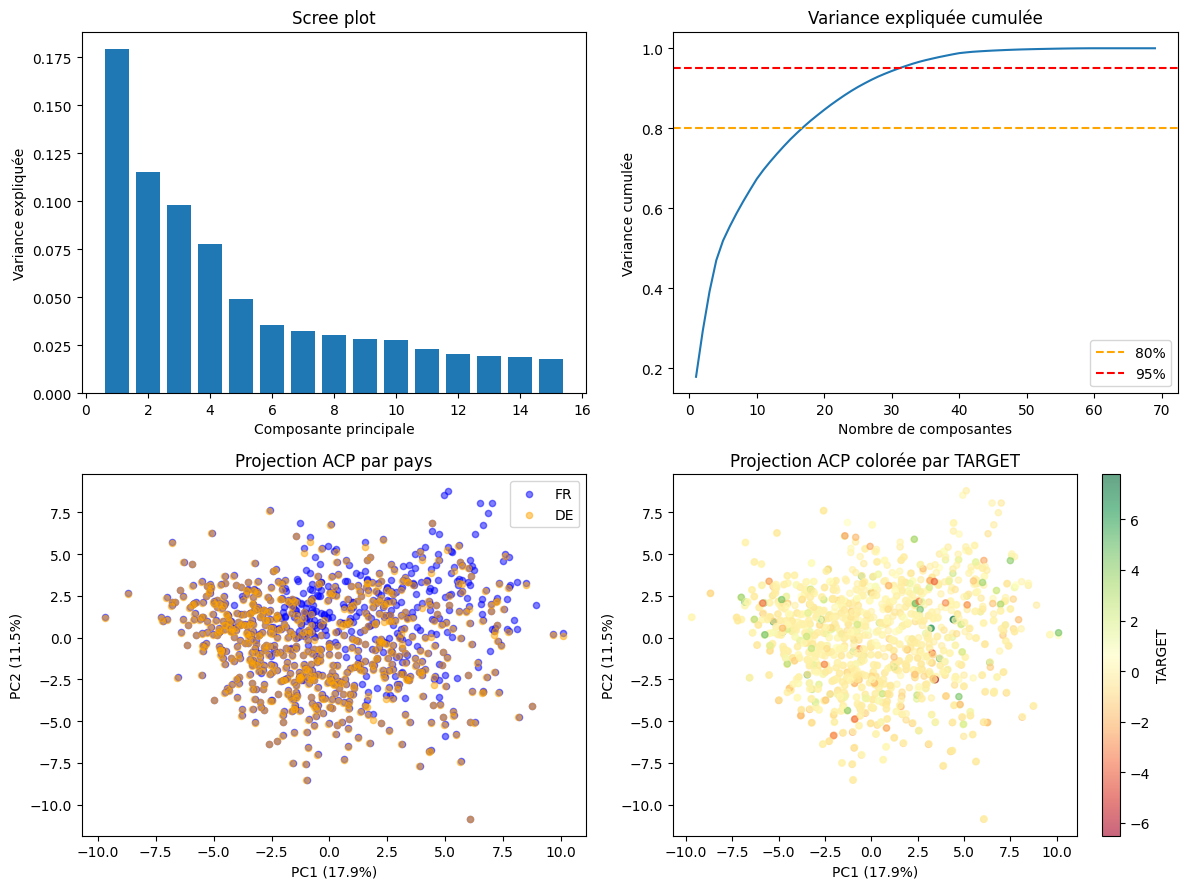

In [ ]:
# ACP sur les features sélectionnées
X_pca = X_train_linear.copy()
country = x_train[['ID','COUNTRY']].set_index('ID').loc[X_pca.index, 'COUNTRY']
target = y_cv.loc[X_pca.index].values

pca = PCA()
X_proj = pca.fit_transform(X_pca)

variance = pca.explained_variance_ratio_
variance_cumulee = np.cumsum(variance)

print("Variance expliquée par les 3 premières composantes :")
print(f"PC1 : {variance[0]:.1%}, PC2 : {variance[1]:.1%}, PC3 : {variance[2]:.1%}")
print(f"Nombre de composantes pour 80% de variance : {np.argmax(variance_cumulee >= 0.80) + 1}")
print(f"Nombre de composantes pour 95% de variance : {np.argmax(variance_cumulee >= 0.95) + 1}")


fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Screen plot
axes[0, 0].bar(range(1, 16), variance[:15])
axes[0, 0].set_xlabel("Composante principale")
axes[0, 0].set_ylabel("Variance expliquée")
axes[0, 0].set_title("Scree plot")

# Variance cumulée
axes[0, 1].plot(range(1, len(variance_cumulee)+1), variance_cumulee)
axes[0, 1].axhline(0.80, color='orange', linestyle='--', label='80%')
axes[0, 1].axhline(0.95, color='red', linestyle='--', label='95%')
axes[0, 1].set_xlabel("Nombre de composantes")
axes[0, 1].set_ylabel("Variance cumulée")
axes[0, 1].set_title("Variance expliquée cumulée")
axes[0, 1].legend()

# Projection par pays
for pays, couleur in [('FR', 'blue'), ('DE', 'orange')]:
    mask = country.values == pays
    axes[1, 0].scatter(X_proj[mask, 0], X_proj[mask, 1], c=couleur, alpha=0.5, s=20, label=pays)
axes[1, 0].set_xlabel(f'PC1 ({variance[0]:.1%})')
axes[1, 0].set_ylabel(f'PC2 ({variance[1]:.1%})')
axes[1, 0].set_title('Projection ACP par pays')
axes[1, 0].legend()

# Projection colorée par TARGET
sc = axes[1, 1].scatter(X_proj[:, 0], X_proj[:, 1], c=target, cmap='RdYlGn', alpha=0.6, s=20)
plt.colorbar(sc, ax=axes[1, 1], label='TARGET')
axes[1, 1].set_xlabel(f'PC1 ({variance[0]:.1%})')
axes[1, 1].set_ylabel(f'PC2 ({variance[1]:.1%})')
axes[1, 1].set_title('Projection ACP colorée par TARGET')

plt.tight_layout()
plt.show()


**Répartition de la variance**
Les valeurs PC1, PC2, PC3 ne présentent aucune domination par l'une des composante. De plus, on remarque une décroissance progressive, sans coude net. La variance est distribuée sur de nombreuses dimensions.

**Variance cumulée - Choix du nombre de composantes**
- 17 composantes : 80% de la variance
- 32 composantes : 95% de la variance

**Graphique par pays**
FR et DE sont fortement mélangés. L'ACP globale n'est pas discriminante entre pays. Cela justifie de faire une ACP séparée par pays.

**Graphique par target**
Aucun gradient clair visible (fortement mélangé).

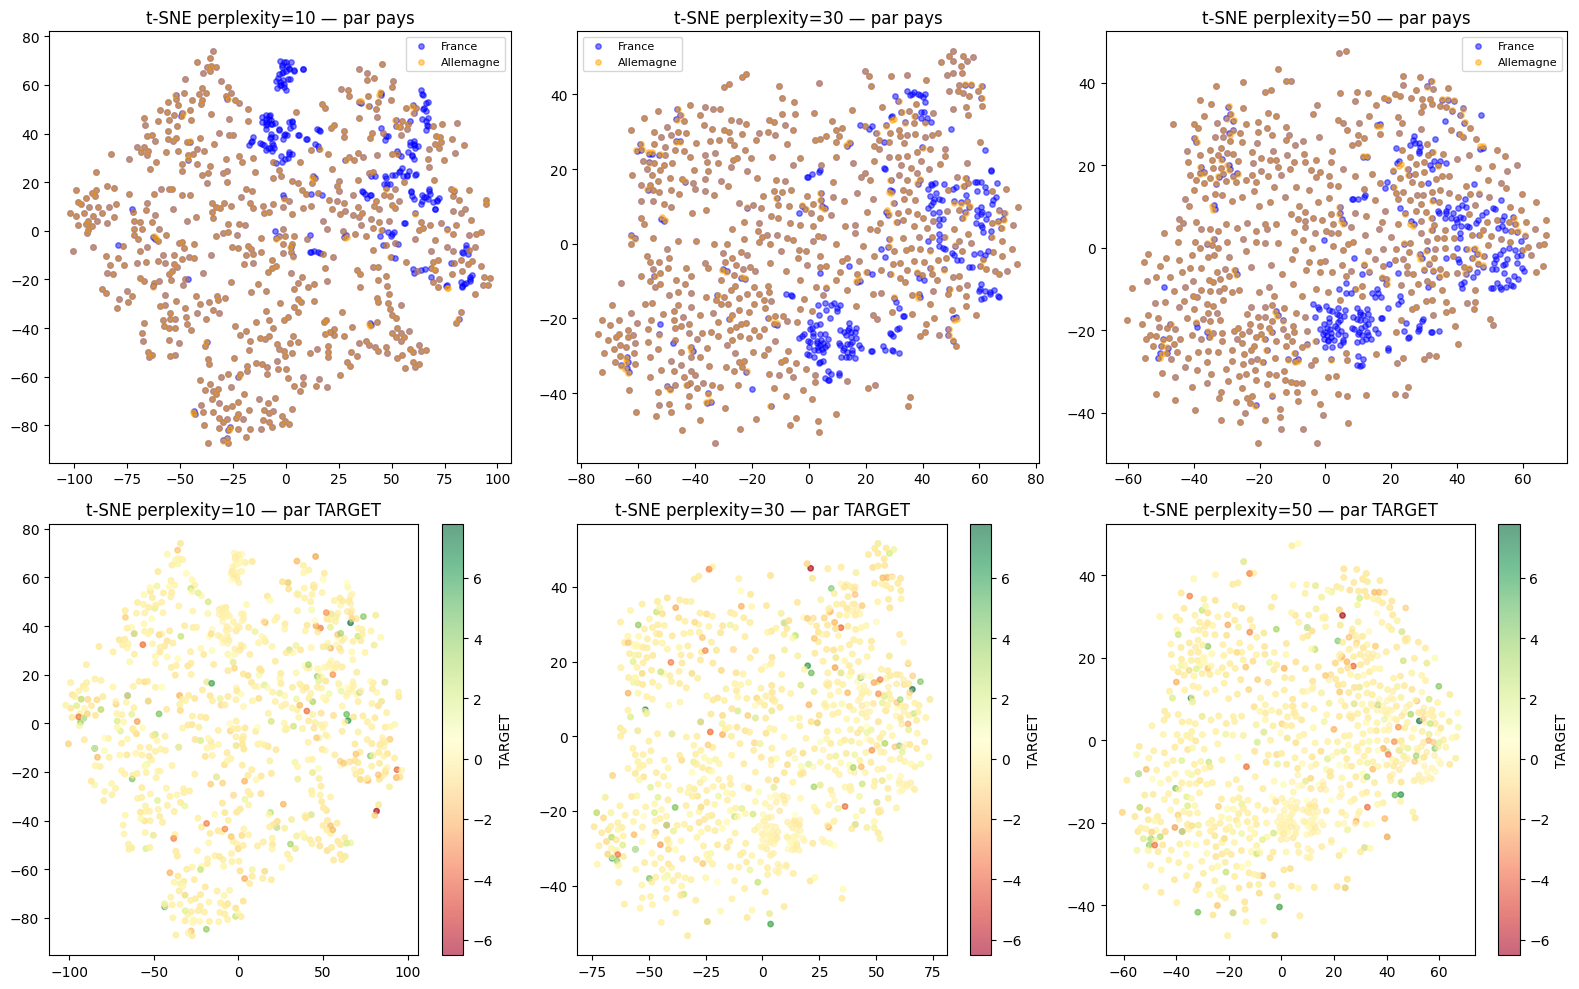

In [ ]:


# Redéfinition au cas où la variable a été écrasée
country = x_train[['ID','COUNTRY']].set_index('ID').loc[X_train_linear.index, 'COUNTRY']

X_pca_50 = PCA(n_components=min(50, X_train_linear.shape[1]),
               random_state=42).fit_transform(X_train_linear)

perplexities = [10, 30, 50]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for col, perp in enumerate(perplexities):
    tsne = TSNE(n_components=2, perplexity=perp,
                max_iter=1000, learning_rate='auto',
                init='pca', random_state=42)
    X_tsne = tsne.fit_transform(X_pca_50)

    for pays, couleur, label in [('FR', 'blue', 'France'), ('DE', 'orange', 'Allemagne')]:
        mask = country.values == pays
        axes[0, col].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                             c=couleur, alpha=0.5, s=15, label=label)
    axes[0, col].set_title(f't-SNE perplexity={perp} — par pays')
    axes[0, col].legend(fontsize=8)

    sc = axes[1, col].scatter(X_tsne[:, 0], X_tsne[:, 1],
                               c=target, cmap='RdYlGn', alpha=0.6, s=15)
    plt.colorbar(sc, ax=axes[1, col], label='TARGET')
    axes[1, col].set_title(f't-SNE perplexity={perp} — par TARGET')

plt.tight_layout()
plt.show()


**Ligne 1 - Coloré par pays**
La France forme un cluster (Nord / Est en bleu) tandis que l'Allemagne est très dispersée dans l'espace. Cela signifie que les jours FR ont des profils similaires entre eux tandis que les jours DE sont plus hétérogènes

**Ligne 2 - Coloré par Target**
Par de gradient spatial clair. Le Target est difficile à prédire.

### Séparation au sein des pays

FR : 851 obs x 42 features
DE : 643 obs x 43 features
France : 23 composantes pour 95% variance
Allemagne : 22 composantes pour 95% variance


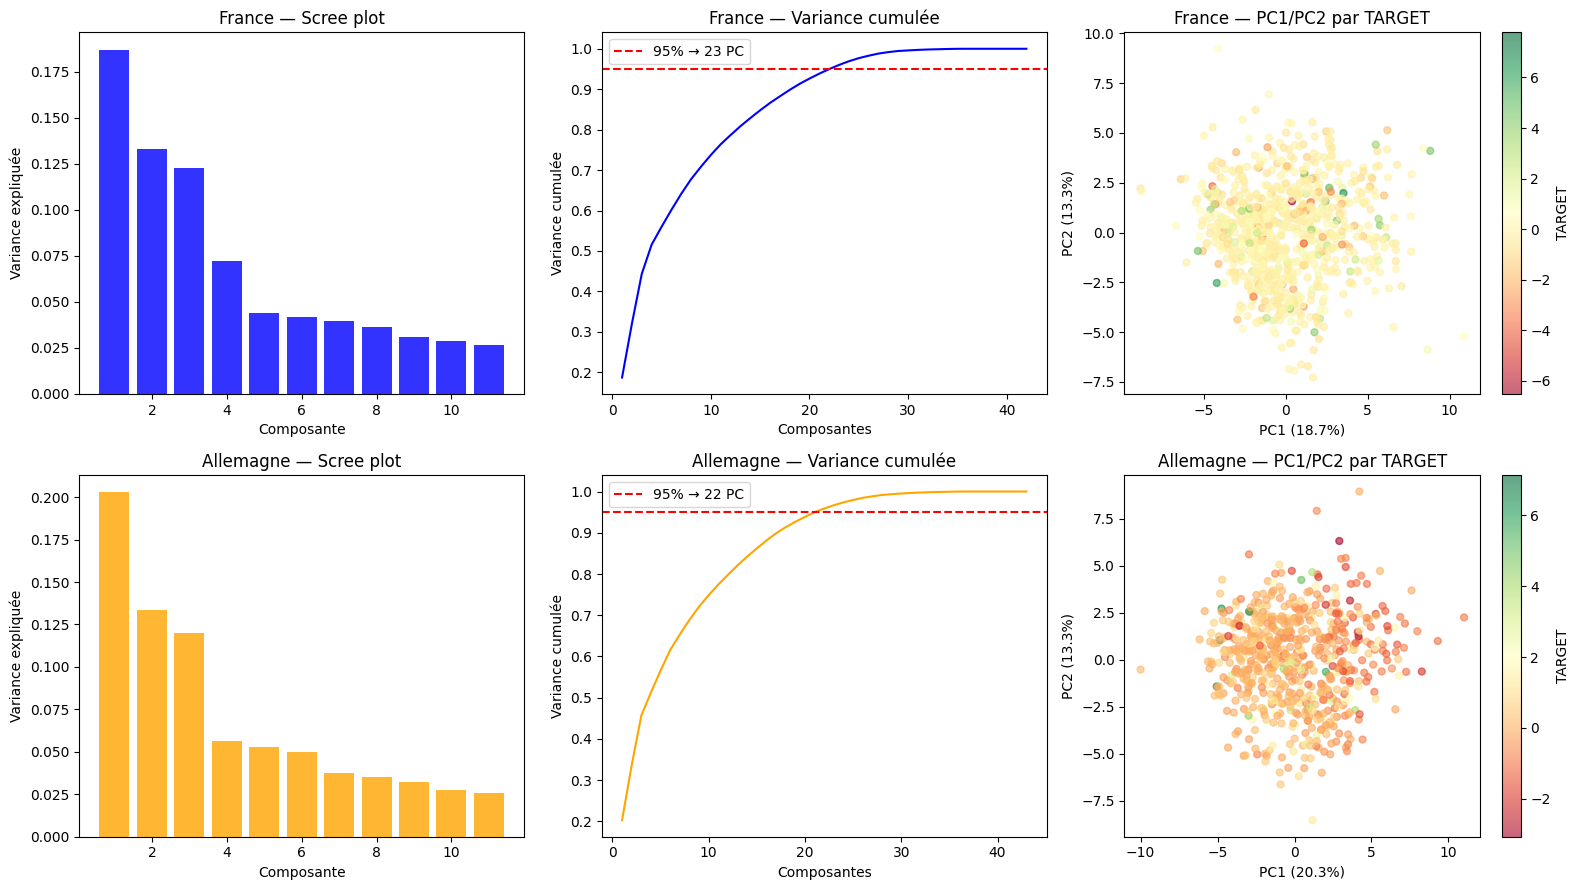

In [ ]:
# Séparation des features par pays
SHARED_FEATS = [f for f in selected_features_perm if not f.startswith('FR_') and not f.startswith('DE_')]
FR_FEATS = [f for f in selected_features_perm if f.startswith('FR_')] + SHARED_FEATS
DE_FEATS = [f for f in selected_features_perm if f.startswith('DE_')] + SHARED_FEATS

mask_fr = country.values == 'FR'
mask_de = country.values == 'DE'

X_fr = X_train_linear[mask_fr][FR_FEATS]
X_de = X_train_linear[mask_de][DE_FEATS]
y_fr = y_cv.loc[X_train_linear.index[mask_fr]].values
y_de = y_cv.loc[X_train_linear.index[mask_de]].values

print(f"FR : {X_fr.shape[0]} obs x {X_fr.shape[1]} features")
print(f"DE : {X_de.shape[0]} obs x {X_de.shape[1]} features")

# ACP par pays
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for row, (X_c, y_c, label, color) in enumerate([
    (X_fr, y_fr, 'France', 'blue'),
    (X_de, y_de, 'Allemagne', 'orange'),
]):
    pca_c = PCA()
    Xp = pca_c.fit_transform(X_c)
    ev = pca_c.explained_variance_ratio_
    cumul_c = np.cumsum(ev)
    n95_c = np.argmax(cumul_c >= 0.95) + 1

    axes[row, 0].bar(range(1, min(12, len(ev)+1)), ev[:11], color=color, alpha=0.8)
    axes[row, 0].set_xlabel('Composante')
    axes[row, 0].set_ylabel('Variance expliquée')
    axes[row, 0].set_title(f'{label} — Scree plot')

    axes[row, 1].plot(range(1, len(cumul_c)+1), cumul_c, color=color)
    axes[row, 1].axhline(0.95, color='red', linestyle='--', label=f'95% → {n95_c} PC')
    axes[row, 1].set_xlabel('Composantes')
    axes[row, 1].set_ylabel('Variance cumulée')
    axes[row, 1].set_title(f'{label} — Variance cumulée')
    axes[row, 1].legend()

    sc = axes[row, 2].scatter(Xp[:, 0], Xp[:, 1], c=y_c, cmap='RdYlGn', alpha=0.6, s=25)
    plt.colorbar(sc, ax=axes[row, 2], label='TARGET')
    axes[row, 2].set_xlabel(f'PC1 ({ev[0]:.1%})')
    axes[row, 2].set_ylabel(f'PC2 ({ev[1]:.1%})')
    axes[row, 2].set_title(f'{label} — PC1/PC2 par TARGET')

    print(f"{label} : {n95_c} composantes pour 95% variance")
    if label == 'France':
        pca_fr, X_pca_fr, n95_fr = pca_c, Xp, n95_c
    else:
        pca_de, X_pca_de, n95_de = pca_c, Xp, n95_c

plt.tight_layout()
plt.show()


Les deux ACP par pays confirment que 22-23 dimensions sont nécessaires pour décrire 95% de la variance (le signal est dans de nombreuses directions). Le TARGET n'est pas capturé par les 2 premières composantes dans aucun des deux pays, ce qui justifie d'utiliser toutes les composantes (pas seulement PC1/PC2) comme input pour le clustering KMeans/GMM qui suit.



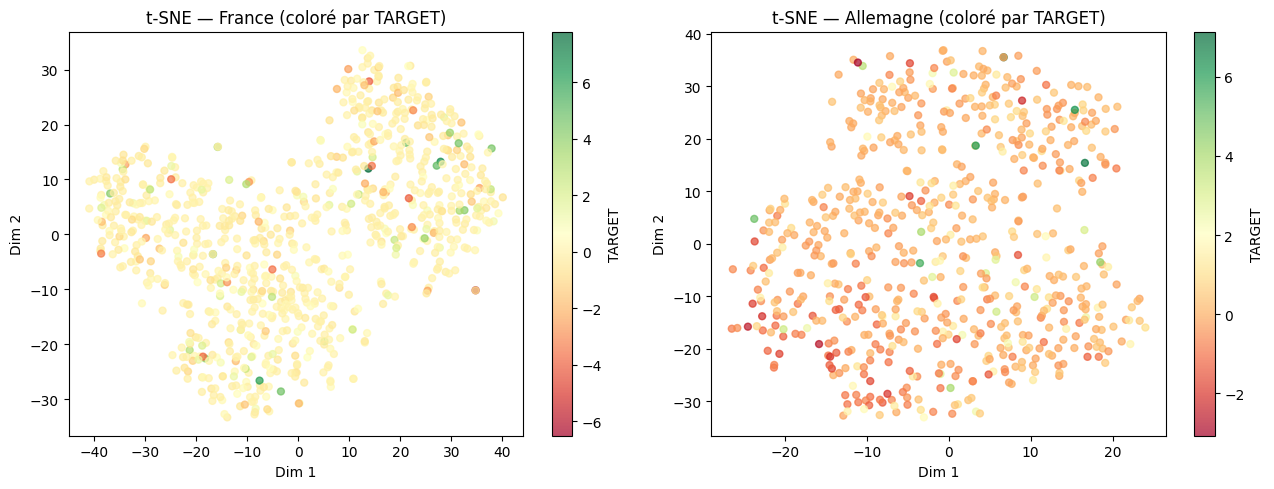

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, X_c, y_c, label in [
    (axes[0], X_fr, y_fr, 'France'),
    (axes[1], X_de, y_de, 'Allemagne'),
]:
    tsne_c = TSNE(n_components=2, perplexity=30,
                  max_iter=1000, learning_rate='auto',
                  init='pca', random_state=42)
    Xt = tsne_c.fit_transform(X_c)

    sc = ax.scatter(Xt[:, 0], Xt[:, 1], c=y_c, cmap='RdYlGn', alpha=0.7, s=25)
    plt.colorbar(sc, ax=ax, label='TARGET')
    ax.set_title(f't-SNE — {label} (coloré par TARGET)')
    ax.set_xlabel('Dim 1')
    ax.set_ylabel('Dim 2')

plt.tight_layout()
plt.show()


Le t-SNE par pays confirme et nuance les résultats précédents :

**France** : structure quasi-aléatoire → signal prix très difficile à capturer, modèle non supervisé limité

**Allemagne** : légère ségrégation spatiale par TARGET → des régimes de marché distincts existent, le clustering a plus de sens pour DE
En pratique, cela suggère que le clustering sera plus utile pour DE que pour FR, et que des modèles séparés par pays restent justifiés.

### Interprétation économique des composantes

In [ ]:
# Interprétation économique des composantes
for label, pca_c, feats in [('France', pca_fr, FR_FEATS), ('Allemagne', pca_de, DE_FEATS)]:

    ev = pca_c.explained_variance_ratio_
    loadings = pd.DataFrame(pca_c.components_[:3].T,
                            index=feats, columns=['PC1','PC2','PC3'])

    print(f"\n{label.upper()}")
    print(f"Les 3 premières composantes expliquent {ev[:3].sum():.1%} de la variance totale.\n")

    for pc in ['PC1','PC2','PC3']:
        idx  = int(pc[2:]) - 1
        top  = loadings[pc].abs().nlargest(5)

        print(f"  {pc} ({ev[idx]:.1%} de la variance)")
        for feat in top.index:
            val      = loadings.loc[feat, pc]
            sens     = "positivement" if val > 0 else "négativement"
            print(f"    {feat} contribue {sens} ({abs(val):.3f})")
        print()

# Matrices réduites pour le clustering
pca_fr_final = PCA(n_components=n95_fr, random_state=42)
pca_de_final = PCA(n_components=n95_de, random_state=42)

X_cluster_fr = pca_fr_final.fit_transform(X_fr)
X_cluster_de = pca_de_final.fit_transform(X_de)

print("Matrices prêtes pour le clustering :")
print(f"  France     : {X_fr.shape[1]} features réduits à {n95_fr} composantes  {X_cluster_fr.shape}")
print(f"  Allemagne  : {X_de.shape[1]} features réduits à {n95_de} composantes  {X_cluster_de.shape}")



FRANCE
Les 3 premières composantes expliquent 44.3% de la variance totale.

  PC1 (18.7% de la variance)
    FR_RESIDUAL_LOAD contribue positivement (0.298)
    FR_CONSUMPTION contribue positivement (0.296)
    FR_GAS contribue positivement (0.290)
    FR_DE_EXCHANGE contribue négativement (0.257)
    NET_FLOW_DE_TO_FR contribue positivement (0.257)

  PC2 (13.3% de la variance)
    FR_NUCLEAR contribue positivement (0.322)
    FR_NET_BALANCE contribue positivement (0.297)
    FR_NET_EXPORT contribue positivement (0.297)
    FR_TRADE_BALANCE contribue positivement (0.297)
    FR_NET_IMPORT contribue négativement (0.297)

  PC3 (12.3% de la variance)
    FOSSIL_COST_INDEX contribue positivement (0.390)
    CARBON_RET contribue positivement (0.381)
    COAL_CARBON_COST contribue positivement (0.374)
    GAS_CARBON_COST contribue positivement (0.355)
    COAL_RET contribue positivement (0.317)


ALLEMAGNE
Les 3 premières composantes expliquent 45.6% de la variance totale.

  PC1 (20.3% d

## 6.2) KMeans

### 6.2.1) Ajout des features

Nous allons utiliser un kmeans pour regrouper nos données en cluster et leur ajouter des données qui pourraient être utiles dans notre analyse. 

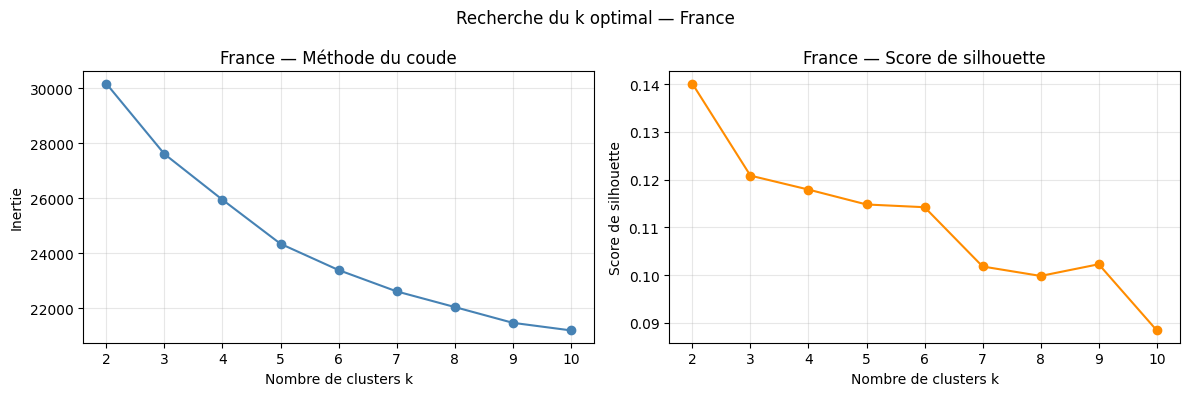

France : meilleur k selon silhouette = 2 (score = 0.140)


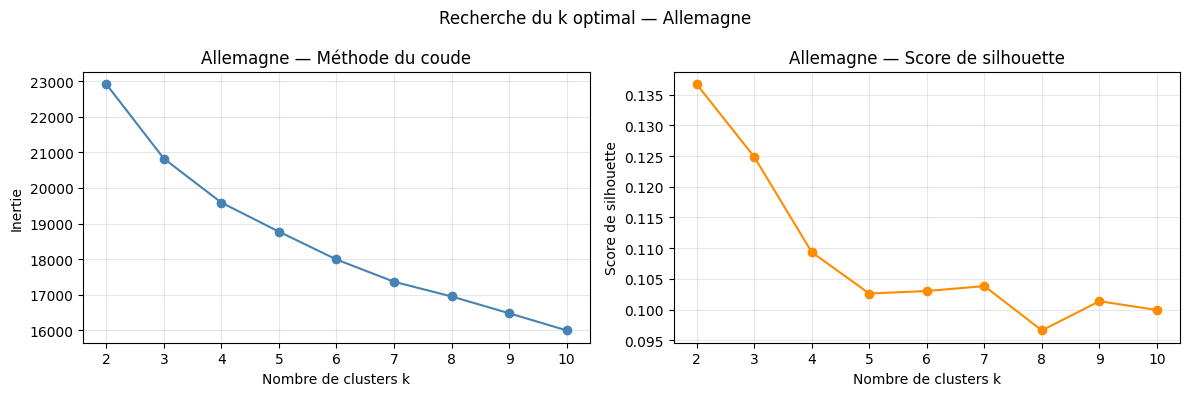

Allemagne : meilleur k selon silhouette = 2 (score = 0.137)


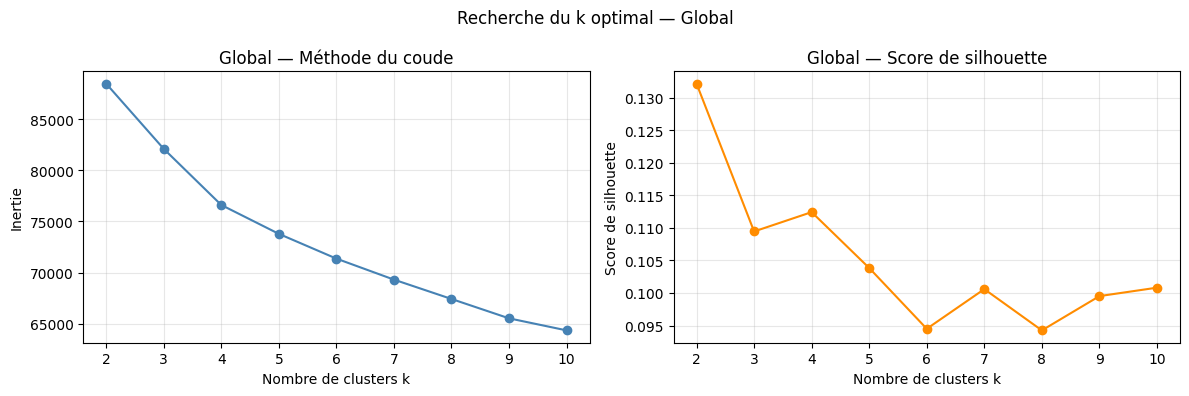

Global : meilleur k selon silhouette = 2 (score = 0.132)


In [ ]:
n95 = np.argmax(variance_cumulee >= 0.95) + 1
pca_all_final = PCA(n_components=n95, random_state=42)
X_cluster_all = pca_all_final.fit_transform(X_train_linear)

def find_k_opt(X, label, k_range=range(2,11)):
    inerties    = []
    silhouettes = []

    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km.fit(X)
        inerties.append(km.inertia_)
        silhouettes.append(silhouette_score(X, km.labels_))

    # Graphiques
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Coude
    axes[0].plot(k_range, inerties, 'o-', color='steelblue')
    axes[0].set(xlabel='Nombre de clusters k', ylabel='Inertie',
                title=f'{label} — Méthode du coude')
    axes[0].grid(True, alpha=0.3)

    # Silhouette
    axes[1].plot(k_range, silhouettes, 'o-', color='darkorange')
    axes[1].set(xlabel='Nombre de clusters k', ylabel='Score de silhouette',
                title=f'{label} — Score de silhouette')
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f'Recherche du k optimal — {label}', fontsize=12)
    plt.tight_layout()
    plt.show()

    k_best = k_range[np.argmax(silhouettes)]
    print(f"{label} : meilleur k selon silhouette = {k_best} "
          f"(score = {max(silhouettes):.3f})")
    return k_best

k_best_fr = find_k_opt(X_cluster_fr, 'France')
k_best_de = find_k_opt(X_cluster_de, 'Allemagne')
k_best_all = find_k_opt(X_cluster_all, 'Global')


Les résultats confirment nos attentes : les données ne présentent pas de structures en clusters forte. 

**Score du coude** Les courbes (méthode du coude) décroissent sans rupture franche.

**Score de silhouette** Les scores sont tous inférieur à 0.25 ce qui est considéré comme faible.

In [ ]:
km_fr  = KMeans(n_clusters=k_best_fr,  random_state=42, n_init=10)
km_de  = KMeans(n_clusters=k_best_de,  random_state=42, n_init=10)
km_all = KMeans(n_clusters=k_best_all, random_state=42, n_init=10)

labels_fr  = km_fr.fit_predict(X_pca_fr)
labels_de  = km_de.fit_predict(X_pca_de)
labels_all = km_all.fit_predict(X_cluster_all)

print(f"France — répartition : {pd.Series(labels_fr).value_counts().sort_index().to_dict()}")
print(f"Allemagne — répartition : {pd.Series(labels_de).value_counts().sort_index().to_dict()}")
print(f"Global — répartition : {pd.Series(labels_all).value_counts().sort_index().to_dict()}")

for label, X_c, labels, feats, y_c in [
    ('France', X_fr,  labels_fr,  FR_FEATS, y_fr),
    ('Allemagne', X_de,  labels_de,  DE_FEATS, y_de),
    ('Global', X_train_linear, labels_all, selected_features_perm,
                  y_cv.loc[X_train_linear.index].values),
]:
    df_c = pd.DataFrame(X_c.values, columns=feats)
    df_c['cluster'] = labels
    df_c['TARGET']  = y_c

    print(f"\n{label.upper()}")
    print(df_c.groupby('cluster')[['TARGET'] + feats[:5]].mean().round(3).to_string())
    print()


France — répartition : {0: 334, 1: 517}
Allemagne — répartition : {0: 279, 1: 364}
Global — répartition : {0: 597, 1: 897}

FRANCE
         TARGET  FR_WIND_SOLAR_PROD  FR_WIND_x_WINDPOW  FR_GAS_COST_x_PROD  FR_WINDPOW  FR_GAS
cluster                                                                                       
0         0.043              -0.321             -0.179              -0.017       0.443   0.807
1         0.048               0.070              0.101              -0.015      -0.346  -0.524


ALLEMAGNE
         TARGET  DE_WINDPOW  DE_RESIDUAL_LOAD  DE_LIGNITE  DE_WIND_SOLAR_PROD  DE_WIND
cluster                                                                               
0        -0.019       0.789            -0.348      -0.116               0.178    0.451
1         0.276      -0.591             0.130      -0.272              -0.033   -0.091


GLOBAL
         TARGET  COUNTRY_FR  DE_WINDPOW  COUNTRY_DE  FR_WIND_SOLAR_PROD  DE_RESIDUAL_LOAD
cluster                       

**Allemagne** :
On remarque deux régimes (éolien et thermique). L'écart de ~0.30 est cohérent avec le merit order effect : les renouvelables évincent les centrales thermiques et font baisser les prix spot. Le clustering capte une structure économique réelle.

**France** :
Ecart de TARGET quasi nul entre clusters. Le nucléaire, à coût marginal fixe, absorbe les variations de renouvelables et de gaz — le prix français y est peu sensible. Cela explique les scores CV plus faibles pour la France (≈ 0.14 vs 0.35 pour l'Allemagne).

**Global** : signal dilué par le mélange des deux pays. 

In [ ]:
day_id_map = x_train[['ID', 'DAY_ID']].set_index('ID')
grp_fr = day_id_map.loc[X_train_linear.index[mask_fr], 'DAY_ID'].values
grp_de = day_id_map.loc[X_train_linear.index[mask_de], 'DAY_ID'].values


ridge = RidgeCV(alphas=np.logspace(-4, 4, 200), cv=10)
gkf   = GroupKFold(n_splits=5)
y_all_vals = y_cv.loc[X_train_linear.index].values

cases = [
    ('France',    X_fr,              labels_fr,  y_fr,       grp_fr),
    ('Allemagne', X_de,              labels_de,  y_de,       grp_de),
    ('Global',    X_train_linear.values, labels_all, y_all_vals, groups),
]

for label, X_c, labels, y_c, grp in cases:
    splits = list(gkf.split(X_c, y_c, groups=grp))
    cv_kw  = dict(cv=splits, scoring=spearman_scorer, n_jobs=-1)

    score_sans  = cross_val_score(ridge, X_c, y_c, **cv_kw)
    cluster_oh  = pd.get_dummies(labels, prefix='cluster').values
    score_avec  = cross_val_score(ridge, np.hstack([X_c, cluster_oh]), y_c, **cv_kw)

    print(f"{label}")
    print(f"  Sans cluster : {score_sans.mean():.4f} ± {score_sans.std():.4f}")
    print(f"  Avec cluster : {score_avec.mean():.4f} ± {score_avec.std():.4f}")
    print(f"  Gain KMeans  : {score_avec.mean() - score_sans.mean():+.4f}\n")


France
  Sans cluster : 0.1300 ± 0.1012
  Avec cluster : 0.1293 ± 0.1013
  Gain KMeans  : -0.0007

Allemagne
  Sans cluster : 0.3485 ± 0.0417
  Avec cluster : 0.3481 ± 0.0410
  Gain KMeans  : -0.0004

Global
  Sans cluster : 0.2114 ± 0.0304
  Avec cluster : 0.2114 ± 0.0304
  Gain KMeans  : -0.0000



## 6.3) Gaussian Mixture Model (GMM)

Étant donné que nos jeu de données s'apparente à des séries temporelles, le GMM peut être performant. C'est un modèle de clustering probabiliste qui suppose que les données suivent un mélange de plusieurs distributions gaussiennes.

Dans notre cas, le GMM apparait comme une confirmation que nos données ne présentent pas de structure en clusters expoitable et de founir une analyse de régimes de marché plus nuancée que KMeans.

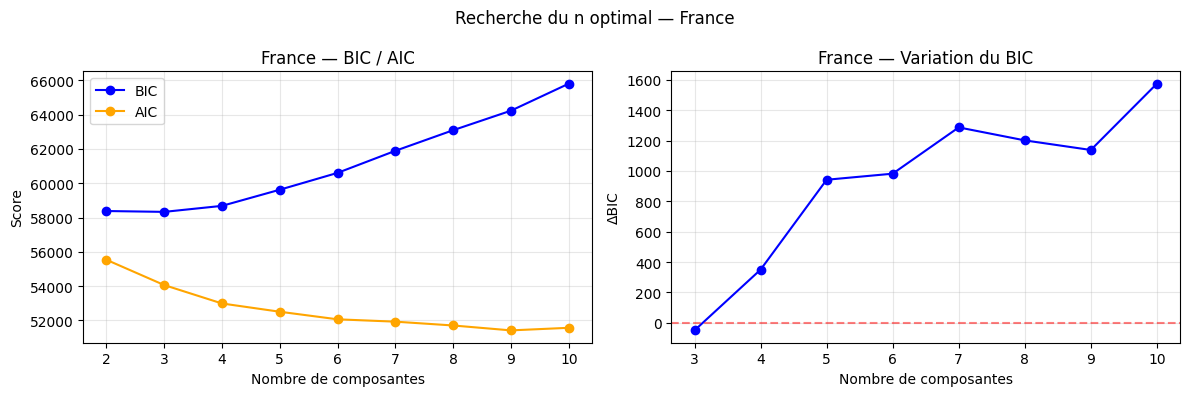

France : meilleur n selon BIC = 3 - selon AIC = 9


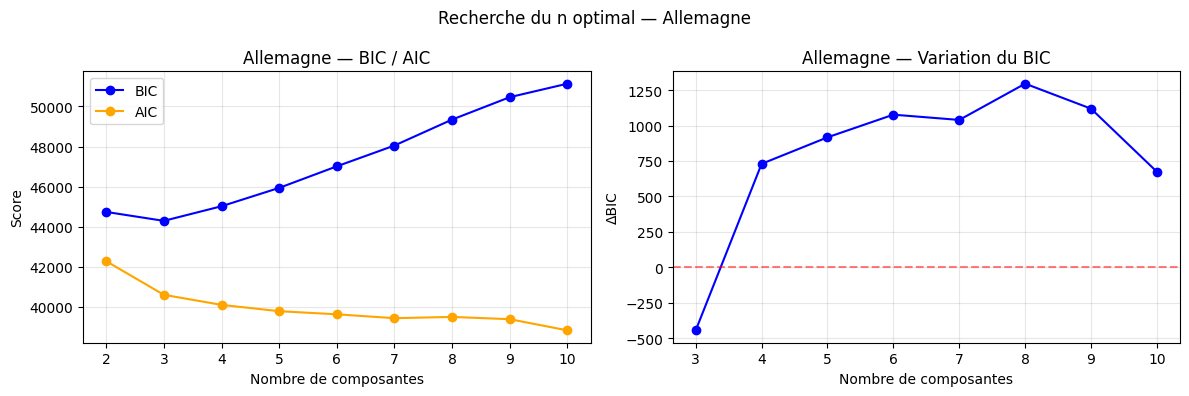

Allemagne : meilleur n selon BIC = 3 - selon AIC = 10


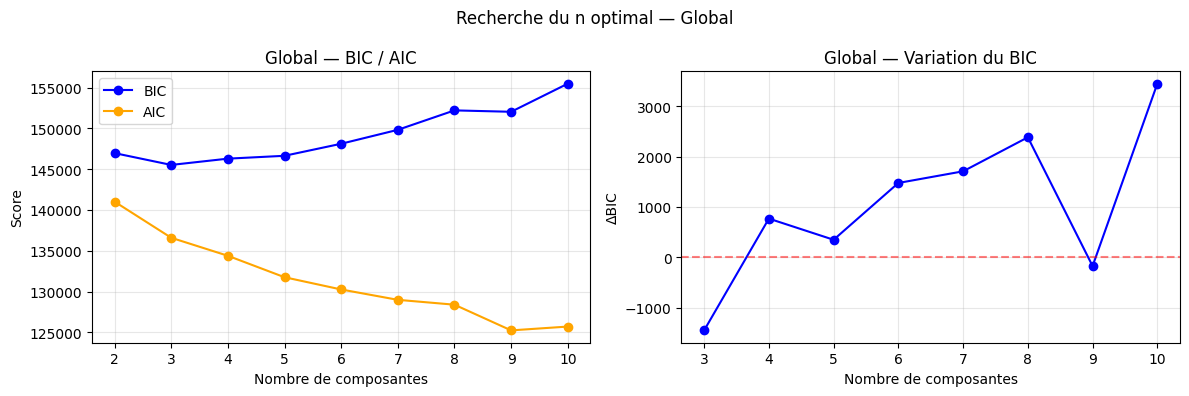

Global : meilleur n selon BIC = 3 - selon AIC = 9


In [ ]:
def chercher_n_gmm(X, label, n_range=range(2, 11)):
    bics, aics = [], []

    for n in n_range:
        gmm = GaussianMixture(n_components=n, covariance_type='full',
                              random_state=42, n_init=5)
        gmm.fit(X)
        bics.append(gmm.bic(X))
        aics.append(gmm.aic(X))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(n_range, bics, 'o-', color='blue', label='BIC')
    axes[0].plot(n_range, aics, 'o-', color='orange', label='AIC')
    axes[0].set(xlabel='Nombre de composantes', ylabel='Score',
                title=f'{label} — BIC / AIC')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Différence pour voir le coude
    bic_diff = np.diff(bics)
    axes[1].plot(list(n_range)[1:], bic_diff, 'o-', color='blue')
    axes[1].axhline(0, color='red', ls='--', alpha=0.5)
    axes[1].set(xlabel='Nombre de composantes', ylabel='ΔBIC',
                title=f'{label} — Variation du BIC')
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f'Recherche du n optimal — {label}', fontsize=12)
    plt.tight_layout()
    plt.show()

    n_best_bic = n_range[np.argmin(bics)]
    n_best_aic = n_range[np.argmin(aics)]
    print(f"{label} : meilleur n selon BIC = {n_best_bic} - selon AIC = {n_best_aic}")
    return n_best_bic

n_gmm_fr  = chercher_n_gmm(X_cluster_fr, 'France')
n_gmm_de  = chercher_n_gmm(X_cluster_de, 'Allemagne')
n_gmm_all = chercher_n_gmm(X_cluster_all, 'Global')


Le BIC pénalise davantage la complexité que l'AIC. Dans notre cas on va choisir BIC car on préfère un modèle plus parcimonieux pour éviter l'overfitting => 3 composantes

In [ ]:
cov_types = ['full', 'tied', 'diag', 'spherical']

print(f"{'Scope':<12} {'cov_type':<12} {'BIC':>10} {'AIC':>10}")

best_gmms = {}
for label, X_c, n_c in [
    ('France', X_cluster_fr,  n_gmm_fr),
    ('Allemagne', X_cluster_de,  n_gmm_de),
    ('Global', X_cluster_all, n_gmm_all),
]:
    best_bic, best_gmm = np.inf, None
    for cov in cov_types:
        gmm = GaussianMixture(n_components=n_c, covariance_type=cov,
                              random_state=42, n_init=5)
        gmm.fit(X_c)
        bic, aic = gmm.bic(X_c), gmm.aic(X_c)
        marker = ' <-- meilleur' if bic < best_bic else ''
        print(f"{label:<12} {cov:<12} {bic:>10.1f} {aic:>10.1f}{marker}")
        if bic < best_bic:
            best_bic, best_gmm = bic, gmm
    best_gmms[label] = best_gmm
    print()

gmm_fr  = best_gmms['France']
gmm_de  = best_gmms['Allemagne']
gmm_all = best_gmms['Global']

labels_gmm_fr  = gmm_fr.predict(X_cluster_fr)
labels_gmm_de  = gmm_de.predict(X_cluster_de)
labels_gmm_all = gmm_all.predict(X_cluster_all)

for label, labels in [('France', labels_gmm_fr),
                       ('Allemagne', labels_gmm_de),
                       ('Global', labels_gmm_all)]:
                       counts = pd.Series(labels).value_counts().sort_index()
                       total=counts.sum()
                       parts = " ".join(f"Cluster {i+1}: {n} ({n/total:.0%})" for i,n in counts.items())
                       print(f"{label:<12} — {parts}")



Scope        cov_type            BIC        AIC
France       full            58333.2    54066.1 <-- meilleur
France       tied            61074.9    59427.9
France       diag            59663.2    58998.7
France       spherical       64324.3    63973.1

Allemagne    full            44287.7    40594.2 <-- meilleur
Allemagne    tied            45371.0    43937.3
Allemagne    diag            43735.1    43136.6 <-- meilleur
Allemagne    spherical       47211.3    46894.2

Global       full           145518.8   136588.8 <-- meilleur
Global       tied           153547.1   150223.6
Global       diag           149892.6   148862.6
Global       spherical      165154.5   164618.3

France       — Cluster 1: 259 (30%) Cluster 2: 246 (29%) Cluster 3: 346 (41%)
Allemagne    — Cluster 1: 132 (21%) Cluster 2: 203 (32%) Cluster 3: 308 (48%)
Global       — Cluster 1: 420 (28%) Cluster 2: 684 (46%) Cluster 3: 390 (26%)


La covariance 'full' est plus flexible : chaque composante a sa propre matrice de corrélation.

La répartition en 3 clusters est déséquilibrée pour l'Allemagne (21% / 32% / 48%) :
le cluster 3 capture le régime dominant (jours "normaux"), les clusters 1 et 2 isolent
des régimes extrêmes moins fréquents (fort éolien, fort thermique).
Pour la France et le Global, la répartition est plus équilibrée (~28–46%).


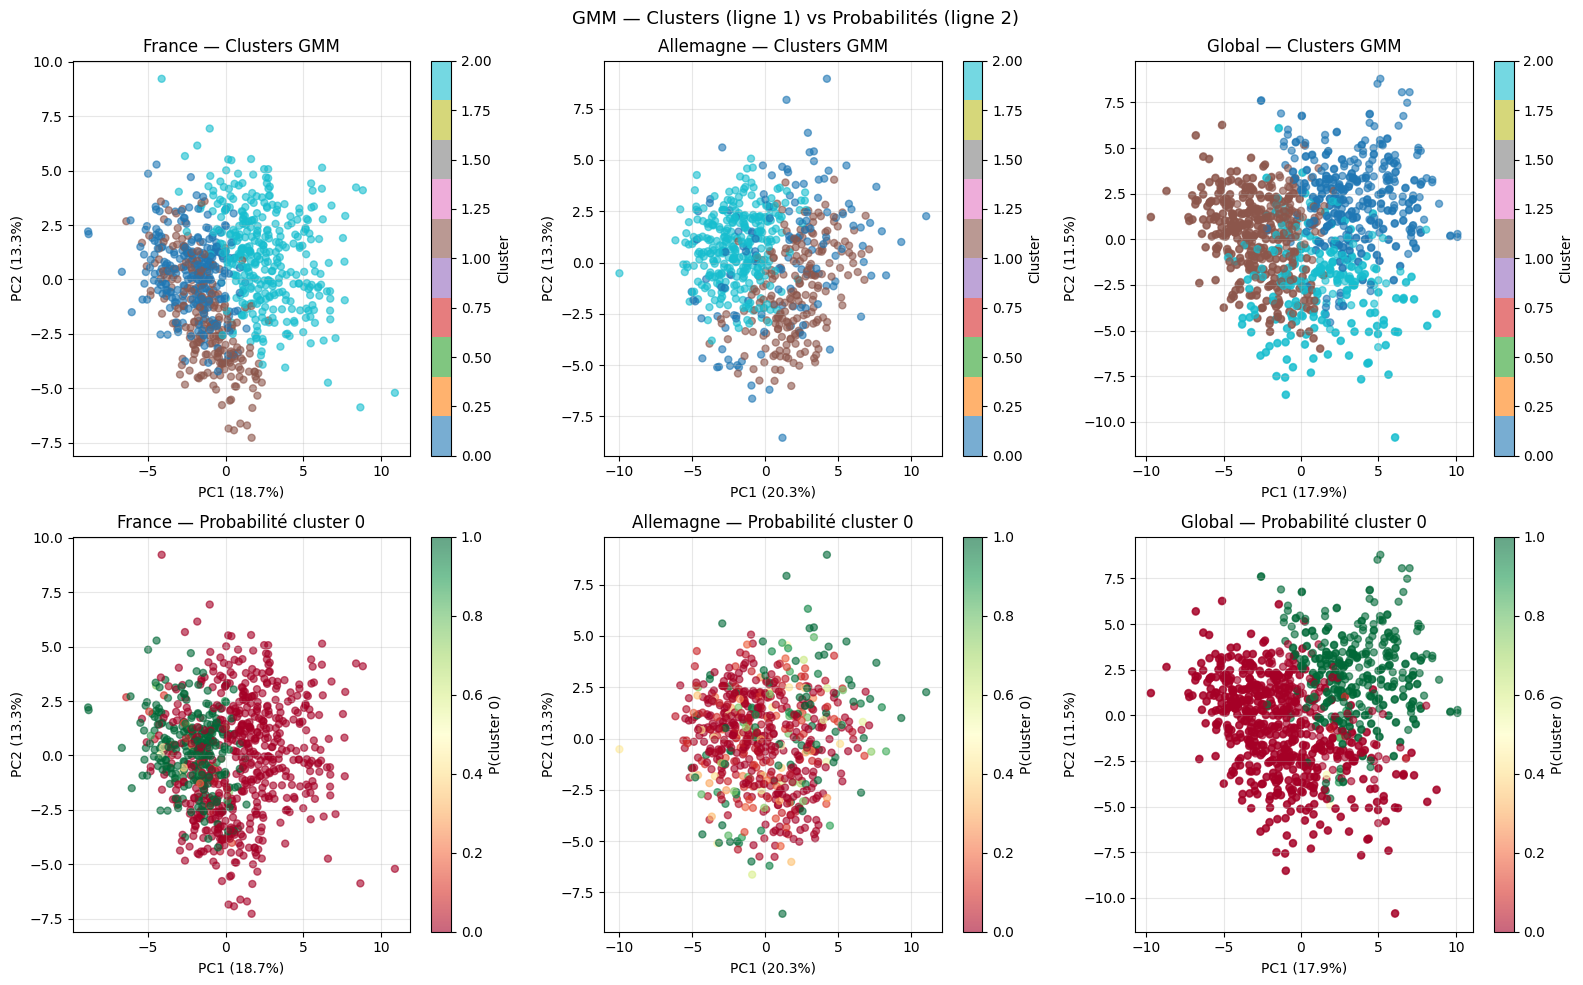

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for col, (X_pca_2d, X_c, gmm_c, labels, label, ev) in enumerate([
    (X_pca_fr[:, :2], X_pca_fr[:, :n95_fr], gmm_fr,  labels_gmm_fr,  'France',    pca_fr.explained_variance_ratio_),
    (X_pca_de[:, :2], X_pca_de[:, :n95_de], gmm_de,  labels_gmm_de,  'Allemagne', pca_de.explained_variance_ratio_),
    (X_proj[:, :2],   X_cluster_all,         gmm_all, labels_gmm_all, 'Global',    pca_all_final.explained_variance_ratio_),
]):

    # Ligne 1 : clusters GMM (hard assignment)
    sc = axes[0, col].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                               c=labels, cmap='tab10', alpha=0.6, s=25)
    plt.colorbar(sc, ax=axes[0, col], label='Cluster')
    axes[0, col].set(xlabel=f'PC1 ({ev[0]:.1%})', ylabel=f'PC2 ({ev[1]:.1%})',
                     title=f'{label} — Clusters GMM')
    axes[0, col].grid(True, alpha=0.3)

    # Ligne 2 : probabilité d'appartenance au cluster 0 (soft assignment)
    proba = gmm_c.predict_proba(X_c)[:, 0]
    sc2 = axes[1, col].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                                c=proba, cmap='RdYlGn', alpha=0.6, s=25,
                                vmin=0, vmax=1)
    plt.colorbar(sc2, ax=axes[1, col], label='P(cluster 0)')
    axes[1, col].set(xlabel=f'PC1 ({ev[0]:.1%})', ylabel=f'PC2 ({ev[1]:.1%})',
                     title=f'{label} — Probabilité cluster 0')
    axes[1, col].grid(True, alpha=0.3)

plt.suptitle('GMM — Clusters (ligne 1) vs Probabilités (ligne 2)', fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:
print(f"{'Scope':<12} {'KMeans':>10} {'GMM hard':>10} {'GMM soft':>12}")
print('-' * 48)

y_all_vals = y_cv.loc[X_train_linear.index].values
groups     = day_id_map.loc[X_train_linear.index, 'DAY_ID'].values

gkf = GroupKFold(n_splits=5)
r   = RidgeCV(alphas=np.logspace(-4, 4, 200), cv=10)

for label, X_c, labels_km, gmm_c, X_gmm, y_c, grp in [
    ('France',    X_fr.values,   labels_fr,  gmm_fr,  X_pca_fr[:, :n95_fr], y_fr,       grp_fr),
    ('Allemagne', X_de.values,   labels_de,  gmm_de,  X_pca_de[:, :n95_de], y_de,       grp_de),
    ('Global',    X_train_linear.values,  labels_all, gmm_all, X_cluster_all,         y_all_vals, groups),
]:
    cv = list(gkf.split(X_c, y_c, groups=grp))

    # KMeans (one-hot)
    s_km = cross_val_score(r, np.hstack([X_c, pd.get_dummies(labels_km, prefix='c').values]),
                           y_c, cv=cv, scoring=spearman_scorer, n_jobs=-1)

    # GMM hard (one-hot)
    labels_gmm = gmm_c.predict(X_gmm)
    s_gmm_h = cross_val_score(r, np.hstack([X_c, pd.get_dummies(labels_gmm, prefix='c').values]),
                               y_c, cv=cv, scoring=spearman_scorer, n_jobs=-1)

    # GMM soft (probabilités)
    s_gmm_s = cross_val_score(r, np.hstack([X_c, gmm_c.predict_proba(X_gmm)]),
                               y_c, cv=cv, scoring=spearman_scorer, n_jobs=-1)

    print(f"{label:<12} {s_km.mean():>10.4f} {s_gmm_h.mean():>10.4f} {s_gmm_s.mean():>12.4f}")


Scope            KMeans   GMM hard     GMM soft
------------------------------------------------


France           0.1293     0.1298       0.1299
Allemagne        0.3481     0.3462       0.3464
Global           0.2114     0.2109       0.2108


ni KMeans ni GMM n'apportent un gain structurel. Les données ne se divisent pas en régimes distincts exploitables pour la prédiction, ce qui confirme que c'est un problème de régression continue, pas de régimes discrets.



# 8) Modèle supervisé

## 8.1) Classification

## 8.2) Regression

## 8.3) Modèle d'ensemble

# 9) Intéprétation des modèles

# 10) Modèles de Deep Learning

## 10.1) Réseau de Neurone Standard

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential, regularizers
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [ ]:
X = x_train_median.set_index("ID")[selected_features_perm].to_numpy(dtype="float32")
y = y_train_clean.to_numpy(dtype="float32")

print(X.shape)
print(y.shape)

(1494, 69)
(1494,)


### 10.1.1) Définition de la métrique de Spearman pour Kéras

In [ ]:
def spearman_metric(y_true, y_pred):
    '''
    Métrique de Spearman pour Keras afin de l'utiliser pour le training
    On va optimiser MSE en monitorant Spearman
    '''
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true_centered = y_true - tf.reduce_mean(y_true)
    y_pred_centered = y_pred - tf.reduce_mean(y_pred)

    numerator = tf.reduce_sum(y_true_centered * y_pred_centered)

    denominator = (tf.sqrt(tf.reduce_sum(y_true_centered**2)) * 
                    tf.sqrt(tf.reduce_sum(y_pred_centered**2)) + 1e-8)
    
    return numerator / denominator

### 10.1.2) Construction du réseau de neurones

Chaque neurone fait : output = f(w*input + bias) avec f la fonction d'activation (ReLu, sigmoid, linear...).

**ReLu Activation** f(x) = max(0, x) -> évite le problème de gradient (utiliser dans les couches cachées)

**Linear activation** f(x) = x -> utilisée en sortie pour la regression

**L2 Regularitsation** pénalise les poids trop grands

In [ ]:
def build_model(input_dim, hidden_layers):
    '''Construction du réseau de neurones'''

    # Sequential = modèle linéaire
    model = Sequential()

    # Couche 1
    model.add(Dense(
        hidden_layers[0], 
        activation="relu",
        kernel_regularizer=regularizers.l2(0.001),
        input_shape=(input_dim,)
    ))
    model.add(Dropout(0.3))

    # Couches suivantes :
    for n_neurons in hidden_layers[1:]:
        model.add(Dense(
            n_neurons,
            activation="relu",
            kernel_regularizer=regularizers.l2(0.001),
        ))
        model.add(Dropout(0.3))
    
    # Couche de sortie
    model.add(Dense(1, activation="linear"))
    return model

# Defintiion des splits GroupKFold
groups    = x_train_median['DAY_ID'].values
gkf_nn    = GroupKFold(n_splits=5)
cv_splits = list(gkf_nn.split(X, y, groups=groups))

# Comparaison des architectures

architectures = {
    "petite" : [32, 16],
    "moyenne" : [128, 64, 32],
    "grande" : [256, 128, 64, 32]
}

results_archi = {}

for nom, layers in architectures.items():
    print(f"Architecture {nom} : {layers}")
    fold_scores = []
    oof = np.zeros(len(y))

    for fold, (tr_idx, val_idx) in enumerate(cv_splits):
        X_tr, X_val = X[tr_idx], X[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]

        model = build_model(X.shape[1], layers)
        model.compile(optimizer='adam', loss='mse', metrics=[spearman_metric])

        model.fit(
            X_tr, y_tr,
            epochs=200,
            batch_size=32,
            validation_data=(X_val, y_val),
            callbacks=[EarlyStopping(monitor='val_loss', patience=20,
                        restore_best_weights=True, verbose=0)],
            verbose=0
        )

        preds = model.predict(X_val, verbose=0).flatten()
        oof[val_idx] = preds
        rho = spearmanr(y_val, preds).correlation
        fold_scores.append(rho)
        print(f"Fold {fold+1}, Spearman = {rho:.4f}")

    rho_oof = spearmanr(y, oof).correlation
    results_archi[nom] = {

        "cv_mean" : np.mean(fold_scores),
        "cv_std"  : np.std(fold_scores),
        "oof"     : rho_oof,
        "layers"  : layers
    }
    print(f"  OOF : {rho_oof:.4f} | CV : {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")

# ── Tableau récapitulatif ─────────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"{'Architecture':<10} {'Couches':<20} {'CV Spearman':>12} {'OOF':>8}")
print(f"{'='*55}")
for nom, res in sorted(results_archi.items(), key=lambda x: -x[1]['oof']):
    print(f"{nom:<10} {str(res['layers']):<20} {res['cv_mean']:>8.4f} ± {res['cv_std']:.2f} {res['oof']:>8.4f}")
print(f"{'='*55}")



Architecture petite : [32, 16]


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1, Spearman = 0.1664
Fold 2, Spearman = 0.1130
Fold 3, Spearman = 0.1919
Fold 4, Spearman = 0.1288
Fold 5, Spearman = 0.2343
  OOF : 0.1301 | CV : 0.1669 ± 0.0436
Architecture moyenne : [128, 64, 32]
Fold 1, Spearman = 0.1816
Fold 2, Spearman = 0.2089
Fold 3, Spearman = 0.1193
Fold 4, Spearman = 0.1590
Fold 5, Spearman = 0.2291
  OOF : 0.1700 | CV : 0.1796 ± 0.0384
Architecture grande : [256, 128, 64, 32]
Fold 1, Spearman = 0.2369
Fold 2, Spearman = 0.2581
Fold 3, Spearman = 0.1556
Fold 4, Spearman = 0.1488
Fold 5, Spearman = 0.2513
  OOF : 0.2044 | CV : 0.2101 ± 0.0479

Architecture Couches               CV Spearman      OOF
grande     [256, 128, 64, 32]     0.2101 ± 0.05   0.2044
moyenne    [128, 64, 32]          0.1796 ± 0.04   0.1700
petite     [32, 16]               0.1669 ± 0.04   0.1301


Pour chaque architecture on entraine le modèle sur 4 folds, on prédit sur le fold restant, on calcule le Spearman sur les prédiction oof et on stocke les résultats

### 10.1.3) Visualisation des courbes d'apprentissage

- training loss baisse mais vl_loss remonte => overfit
- les deux descendent ensemble => bon apprentissage
- les deux stagnent => underfit

In [ ]:
best_archi = max(results_archi.items(), key=lambda x: x[1]['oof'])
best_layers = best_archi[1]['layers']
print(f"\nMeilleure architecture : {best_archi[0]} {best_layers}")

# Réentraînement sur le dernier fold pour récupérer l'historique
tr_idx, val_idx = cv_splits[-1]
X_tr, X_val = X[tr_idx], X[val_idx]
y_tr, y_val = y[tr_idx], y[val_idx]

model_best = build_model(X.shape[1], best_layers)
model_best.compile(optimizer='adam', loss='mse', metrics=[spearman_metric])

history_best = model_best.fit(
    X_tr, y_tr,
    epochs=200,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[EarlyStopping(monitor='val_loss', patience=20,
                             restore_best_weights=True, verbose=0)],
    verbose=0
)


Meilleure architecture : grande [256, 128, 64, 32]


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


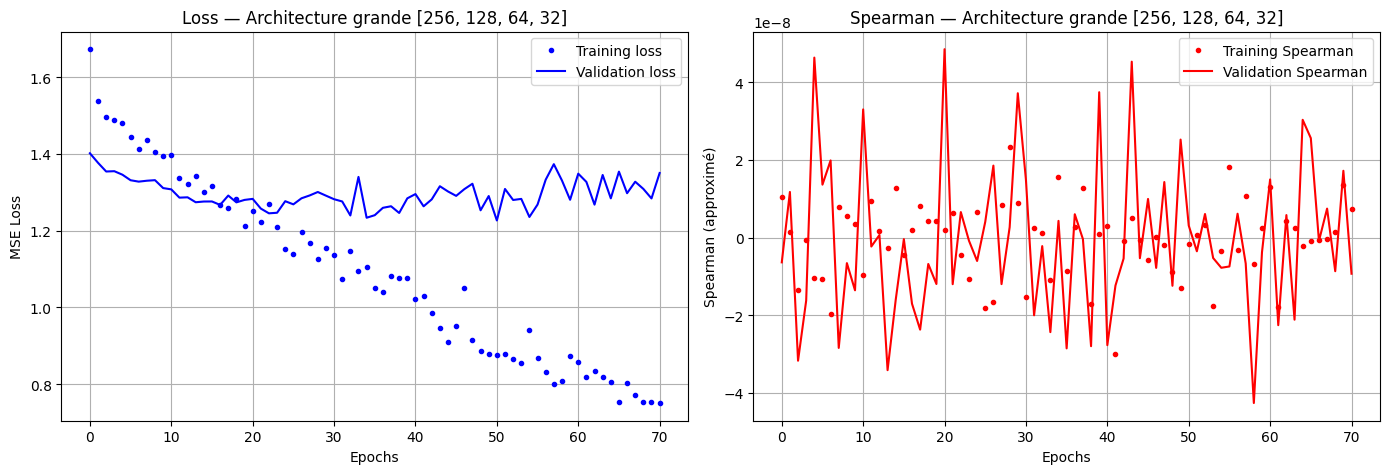

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_best.history['loss'], 'bo', label='Training loss',   markersize=3)
axes[0].plot(history_best.history['val_loss'], 'b', label='Validation loss')
axes[0].set_title(f'Loss — Architecture {best_archi[0]} {best_layers}')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(True)

# Graphe 2 : Spearman approximé
axes[1].plot(history_best.history['spearman_metric'], 'ro', label='Training Spearman',   markersize=3)
axes[1].plot(history_best.history['val_spearman_metric'], 'r', label='Validation Spearman')
axes[1].set_title(f'Spearman — Architecture {best_archi[0]} {best_layers}')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Spearman (approximé)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

On remarque un overfit classique. Le modèle apprend bien sur le train mais ne se généralise pas. De plus, le modèle n'apprend aucune corrélation. Le réseau de neurone est inadapté à ce probleme : le dataset est trop petit, le signal dans les données est faible et linéaire.

# MLP + BatchNorm

In [ ]:
# =========================================================================
# APPROCHE 1 — MLP avec Batch Normalization
# =========================================================================
# Batch Normalization : normalise les sorties de chaque couche
# → stabilise l'apprentissage, réduit l'overfit, accélère la convergence
# → s'applique AVANT l'activation (Dense → BN → ReLU → Dropout)

from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Activation

def build_model_bn(input_dim, hidden_layers):
    """
    MLP avec Batch Normalization.
    
    Différence avec le MLP standard :
    - Standard : Dense(relu) → Dropout
    - Avec BN  : Dense → BatchNorm → ReLU → Dropout
    
    BatchNormalization :
    → normalise les activations (moyenne=0, std=1) à chaque batch
    → évite que certains neurones saturent (valeurs trop grandes/petites)
    → permet un learning rate plus élevé → apprentissage plus rapide
    → dropout réduit à 0.2 car BN régularise déjà
    """
    model = Sequential()
    
    # Couche 1
    model.add(Dense(
        hidden_layers[0],
        kernel_regularizer=regularizers.l2(0.001),
        input_shape=(input_dim,)
    ))
    model.add(BatchNormalization())       # normalise avant l'activation
    model.add(Activation('relu'))         # activation après BN
    model.add(Dropout(0.2))              # dropout réduit car BN régularise déjà
    
    # Couches suivantes
    for n_neurons in hidden_layers[1:]:
        model.add(Dense(
            n_neurons,
            kernel_regularizer=regularizers.l2(0.001)
        ))
        model.add(BatchNormalization())
        model.add(Activation('relu'))
        model.add(Dropout(0.2))
    
    # Couche de sortie — linear pour régression
    model.add(Dense(1, activation='linear'))
    
    return model


# ── Entraînement et évaluation ────────────────────────────────────────────
print("=" * 50)
print("APPROCHE 1 — MLP avec Batch Normalization")
print("=" * 50)

oof_bn      = np.zeros(len(y))
scores_bn   = []
best_layers = [256, 128, 64, 32]  # meilleure architecture trouvée avant

for fold, (tr_idx, val_idx) in enumerate(cv_splits):
    X_tr, X_val = X[tr_idx], X[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]
    
    model_bn = build_model_bn(X.shape[1], best_layers)
    model_bn.compile(optimizer='adam', loss='mse', metrics=[spearman_metric])
    
    model_bn.fit(
        X_tr, y_tr,
        epochs=200,
        batch_size=32,
        validation_data=(X_val, y_val),
        callbacks=[EarlyStopping(
            monitor='val_loss',
            patience=20,
            restore_best_weights=True,
            verbose=0
        )],
        verbose=0
    )
    
    preds = model_bn.predict(X_val, verbose=0).flatten()
    oof_bn[val_idx] = preds
    rho = spearmanr(y_val, preds).correlation
    scores_bn.append(rho)
    print(f"  Fold {fold+1} | Spearman : {rho:.4f}")

rho_oof_bn = spearmanr(y, oof_bn).correlation
print(f"\n  OOF : {rho_oof_bn:.4f} | CV : {np.mean(scores_bn):.4f} ± {np.std(scores_bn):.4f}")
print(f"  Référence MLP standard : 0.2044")


# =========================================================================
# APPROCHE 2 — MLP entraîné sur les rangs
# =========================================================================
# Idée : transformer y en rangs avant l'entraînement
# → aligne directement l'optimisation sur Spearman
# → le réseau apprend à prédire l'ORDRE des observations
#   plutôt que les valeurs brutes
#
# Normalisation des rangs entre 0 et 1 :
# → évite que les grandes valeurs de rangs (ex: 1494) causent
#   des problèmes numériques pendant l'entraînement

from scipy.stats import rankdata

print("\n" + "=" * 50)
print("APPROCHE 2 — MLP entraîné sur les rangs")
print("=" * 50)

# Transformation en rangs normalisés entre 0 et 1
# rankdata : [0.05, -0.12, 0.08] → [3, 1, 2] (rang de chaque valeur)
# normalisation : rang / (n-1) → valeurs entre 0 et 1
y_ranked = rankdata(y).astype("float32")
y_ranked = (y_ranked - y_ranked.min()) / (y_ranked.max() - y_ranked.min())

print(f"y original : min={y.min():.3f} | max={y.max():.3f}")
print(f"y ranked   : min={y_ranked.min():.3f} | max={y_ranked.max():.3f}")

oof_rank    = np.zeros(len(y))
scores_rank = []

for fold, (tr_idx, val_idx) in enumerate(cv_splits):
    X_tr,      X_val      = X[tr_idx],      X[val_idx]
    y_tr_rank, y_val_rank = y_ranked[tr_idx], y_ranked[val_idx]
    y_val_orig            = y[val_idx]  # pour évaluer le vrai Spearman
    
    # On utilise la meilleure architecture avec BN
    model_rank = build_model_bn(X.shape[1], best_layers)
    model_rank.compile(optimizer='adam', loss='mse', metrics=[spearman_metric])
    
    # Entraînement sur y_ranked au lieu de y
    model_rank.fit(
        X_tr, y_tr_rank,  # ← y en rangs normalisés
        epochs=200,
        batch_size=32,
        validation_data=(X_val, y_val_rank),
        callbacks=[EarlyStopping(
            monitor='val_loss',
            patience=20,
            restore_best_weights=True,
            verbose=0
        )],
        verbose=0
    )
    
    preds = model_rank.predict(X_val, verbose=0).flatten()
    oof_rank[val_idx] = preds
    
    # Spearman calculé sur les valeurs originales (pas les rangs)
    # car Spearman est invariant à la transformation monotone
    rho = spearmanr(y_val_orig, preds).correlation
    scores_rank.append(rho)
    print(f"  Fold {fold+1} | Spearman : {rho:.4f}")

rho_oof_rank = spearmanr(y, oof_rank).correlation
print(f"\n  OOF : {rho_oof_rank:.4f} | CV : {np.mean(scores_rank):.4f} ± {np.std(scores_rank):.4f}")
print(f"  Référence MLP standard : 0.2044")

# =========================================================================
# APPROCHE 3 — Ensemble Ridge + MLP
# =========================================================================

from sklearn.model_selection import cross_val_predict

# Dans ton notebook main_v5 :
# X_cv = x_train_median.set_index("ID")[feature_cols]
# y_cv = y_train_clean
# groups = x_train_median['DAY_ID'].values
# gkf = GroupKFold(n_splits=5)

ridge_oof = RidgeCV(alphas=np.logspace(-4, 4, 200), cv=10)
preds_ridge_oof = cross_val_predict(
    ridge_oof,
    X_cv[selected_features_perm],  # ← X_cv au lieu de x_train_cv
    y_cv,                           # ← y_cv au lieu de y_train_clean
    cv=list(gkf.split(
        X_cv[selected_features_perm],
        y_cv,
        groups=groups
    ))
)

print(f"Spearman Ridge OOF  : {spearmanr(y, preds_ridge_oof).correlation:.4f}")
print(f"Spearman MLP BN OOF : {spearmanr(y, oof_bn).correlation:.4f}")

# Test de différentes pondérations
print(f"\n{'alpha':>8} {'Spearman ensemble':>20}")
print("-" * 30)

best_alpha_ens = None
best_rho_ens   = -1

for alpha in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    preds_ens = alpha * preds_ridge_oof + (1 - alpha) * oof_bn
    rho_ens   = spearmanr(y, preds_ens).correlation
    print(f"  {alpha:>5} | {rho_ens:>8.4f}")
    if rho_ens > best_rho_ens:
        best_rho_ens   = rho_ens
        best_alpha_ens = alpha

print(f"\nMeilleur alpha : {best_alpha_ens} → Spearman : {best_rho_ens:.4f}")

# ── Tableau récapitulatif ─────────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"{'Approche':<30} {'OOF Spearman':>12}")
print(f"{'='*55}")
print(f"{'Ridge (référence)':<30} {spearmanr(y, preds_ridge_oof).correlation:>12.4f}")
print(f"{'MLP standard':<30} {'0.2044':>12}")
print(f"{'MLP + BatchNorm':<30} {rho_oof_bn:>12.4f}")
print(f"{'MLP sur rangs':<30} {rho_oof_rank:>12.4f}")
print(f"{'Ensemble Ridge + MLP':<30} {best_rho_ens:>12.4f}")
print(f"{'='*55}")

APPROCHE 1 — MLP avec Batch Normalization
  Fold 1 | Spearman : 0.1835
  Fold 2 | Spearman : 0.1400
  Fold 3 | Spearman : 0.2146
  Fold 4 | Spearman : 0.1133
  Fold 5 | Spearman : 0.2304

  OOF : 0.1817 | CV : 0.1764 ± 0.0441
  Référence MLP standard : 0.2044

APPROCHE 2 — MLP entraîné sur les rangs
y original : min=-6.519 | max=7.787
y ranked   : min=0.000 | max=1.000
  Fold 1 | Spearman : 0.2876
  Fold 2 | Spearman : 0.2185
  Fold 3 | Spearman : 0.2378
  Fold 4 | Spearman : 0.2292
  Fold 5 | Spearman : 0.2628

  OOF : 0.2475 | CV : 0.2472 ± 0.0249
  Référence MLP standard : 0.2044
Spearman Ridge OOF  : 0.2119
Spearman MLP BN OOF : 0.1817

   alpha    Spearman ensemble
------------------------------
    0.1 |   0.1906
    0.2 |   0.1995
    0.3 |   0.2076
    0.4 |   0.2151
    0.5 |   0.2201
    0.6 |   0.2224
    0.7 |   0.2226
    0.8 |   0.2205
    0.9 |   0.2165

Meilleur alpha : 0.7 → Spearman : 0.2226

Approche                       OOF Spearman
Ridge (référence)               

In [ ]:
print(f"\n{'alpha':>8} {'Spearman ensemble':>20}")
print("-" * 30)

best_alpha_rank = None
best_rho_rank   = -1

for alpha in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    preds_ens = alpha * preds_ridge_oof + (1 - alpha) * oof_rank
    rho_ens   = spearmanr(y, preds_ens).correlation
    print(f"  {alpha:>5} | {rho_ens:>8.4f}")
    if rho_ens > best_rho_rank:
        best_rho_rank   = rho_ens
        best_alpha_rank = alpha

print(f"\nMeilleur alpha : {best_alpha_rank} → Spearman : {best_rho_rank:.4f}")
print(f"\nComparaison finale :")
print(f"  MLP sur rangs seul          : {spearmanr(y, oof_rank).correlation:.4f}")
print(f"  Ridge seul                  : {spearmanr(y, preds_ridge_oof).correlation:.4f}")
print(f"  Ensemble Ridge + MLP rangs  : {best_rho_rank:.4f}")


   alpha    Spearman ensemble
------------------------------
    0.1 |   0.2550
    0.2 |   0.2614
    0.3 |   0.2655
    0.4 |   0.2658
    0.5 |   0.2638
    0.6 |   0.2586
    0.7 |   0.2503
    0.8 |   0.2397
    0.9 |   0.2258

Meilleur alpha : 0.4 → Spearman : 0.2658

Comparaison finale :
  MLP sur rangs seul          : 0.2475
  Ridge seul                  : 0.2119
  Ensemble Ridge + MLP rangs  : 0.2658


In [ ]:
# =========================================================================
# SOUMISSION FINALE — Ensemble Ridge(40%) + MLP sur rangs(60%)
# =========================================================================

# ── Étape 1 : Entraînement Ridge final sur tout le train ─────────────────
ridge_final = RidgeCV(alphas=np.logspace(-4, 4, 200), cv=10)
ridge_final.fit(X_cv[selected_features_perm], y_cv)
print(f"Alpha Ridge sélectionné : {ridge_final.alpha_}")

# ── Étape 2 : Entraînement MLP sur rangs final sur tout le train ─────────
# Transformation en rangs normalisés
y_ranked_full = rankdata(y).astype("float32")
y_ranked_full = (y_ranked_full - y_ranked_full.min()) / (y_ranked_full.max() - y_ranked_full.min())

# On entraîne le MLP sur tout le train (pas de CV ici)
model_rank_final = build_model(X.shape[1], [256, 128, 64, 32])
model_rank_final.compile(optimizer='adam', loss='mse', metrics=[spearman_metric])

model_rank_final.fit(
    X, y_ranked_full,
    epochs=200,
    batch_size=32,
    validation_split=0.1,  # 10% pour EarlyStopping
    callbacks=[EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True,
        verbose=0
    )],
    verbose=0
)
print("MLP sur rangs entraîné !")

# ── Étape 3 : Prédictions sur X_test ─────────────────────────────────────
X_test_final = x_test_median.set_index("ID")[selected_features_perm].to_numpy(dtype="float32")

# Prédiction Ridge
preds_ridge_test = ridge_final.predict(
    x_test_median.set_index("ID")[selected_features_perm]
)

# Prédiction MLP sur rangs
preds_mlp_test = model_rank_final.predict(X_test_final, verbose=0).flatten()

# ── Étape 4 : Ensemble ────────────────────────────────────────────────────
best_alpha_rank = 0.4  # Ridge 40%, MLP rangs 60%
preds_ensemble  = best_alpha_rank * preds_ridge_test + (1 - best_alpha_rank) * preds_mlp_test

# ── Étape 5 : Fichier de soumission ──────────────────────────────────────
submission = pd.DataFrame({
    "ID":     x_test_median["ID"].values,
    "TARGET": preds_ensemble
})

# Vérifications
assert submission.shape == (654, 2),              f"Shape incorrecte : {submission.shape}"
assert submission["TARGET"].isna().sum() == 0,    "NaN détectés dans TARGET !"
assert set(submission["ID"]) == set(x_test["ID"]), "ID incorrects !"

print(f"\nShape       : {submission.shape}")
print(f"TARGET mean : {submission['TARGET'].mean():.4f}")
print(f"TARGET std  : {submission['TARGET'].std():.4f}")
print(submission.head(10))

submission.to_csv("submission_ensemble_ridge_mlp_rank.csv", index=False)
print("\nFichier 'submission_ensemble_ridge_mlp_rank.csv' sauvegardé !")

# TEST

In [ ]:
# =========================================================================
# OPTIMISATION COMPLÈTE — Ensemble Ridge + MLP rangs + LightGBM
# =========================================================================

from itertools import product
from lightgbm import LGBMRegressor
from scipy.stats import rankdata
from sklearn.model_selection import cross_val_predict
import numpy as np

# -------------------------------------------------------------------------
# ÉTAPE 1 — Tuning des hyperparamètres du MLP sur rangs
# -------------------------------------------------------------------------
# On cherche la meilleure combinaison de :
# - architecture (nombre et taille des couches)
# - dropout (taux d'extinction des neurones)
# - l2 (force de la régularisation)
# - batch_size (taille des batchs)
# - optimizer (algorithme d'optimisation)

print("=" * 60)
print("ÉTAPE 1 — Tuning MLP sur rangs")
print("=" * 60)

def build_model_tunable(input_dim, hidden_layers, dropout, l2):
    """MLP sur rangs avec hyperparamètres configurables."""
    model = Sequential()
    # Couche 1
    model.add(Dense(
        hidden_layers[0],
        kernel_regularizer=regularizers.l2(l2),
        input_shape=(input_dim,)
    ))
    model.add(Activation('relu'))
    model.add(Dropout(dropout))
    # Couches suivantes
    for n in hidden_layers[1:]:
        model.add(Dense(n, kernel_regularizer=regularizers.l2(l2)))
        model.add(Activation('relu'))
        model.add(Dropout(dropout))
    # Sortie
    model.add(Dense(1, activation='linear'))
    return model

# Grille d'hyperparamètres
# Version rapide — seulement les combinaisons les plus prometteuses
param_grid_mlp = {
    'hidden_layers' : [[256, 128, 64, 32], [512, 256, 128, 64]],
    'dropout'       : [0.1, 0.2],
    'l2'            : [0.0001, 0.001],
    'batch_size'    : [32],
    'optimizer'     : ['adam'],
}
# → 8 combinaisons × 5 folds = 40 entraînements seulement

results_tuning = []
total_configs  = (len(param_grid_mlp['hidden_layers']) *
                  len(param_grid_mlp['dropout']) *
                  len(param_grid_mlp['l2']) *
                  len(param_grid_mlp['batch_size']) *
                  len(param_grid_mlp['optimizer']))
print(f"Nombre de configurations à tester : {total_configs}")

for idx, (layers, dropout, l2, batch_size, optimizer) in enumerate(product(
    param_grid_mlp['hidden_layers'],
    param_grid_mlp['dropout'],
    param_grid_mlp['l2'],
    param_grid_mlp['batch_size'],
    param_grid_mlp['optimizer'],
)):
    oof_tuned  = np.zeros(len(y))

    for tr_idx, val_idx in cv_splits:
        X_tr, X_val     = X[tr_idx], X[val_idx]
        y_tr_r, y_val_r = y_ranked[tr_idx], y_ranked[val_idx]
        y_val_orig      = y[val_idx]

        m = build_model_tunable(X.shape[1], layers, dropout, l2)
        m.compile(optimizer=optimizer, loss='mse')
        m.fit(
            X_tr, y_tr_r,
            epochs=200,
            batch_size=batch_size,
            validation_data=(X_val, y_val_r),
            callbacks=[EarlyStopping(
                monitor='val_loss',
                patience=20,
                restore_best_weights=True,
                verbose=0
            )],
            verbose=0
        )
        preds = m.predict(X_val, verbose=0).flatten()
        oof_tuned[val_idx] = preds

    rho = spearmanr(y, oof_tuned).correlation
    results_tuning.append({
        'layers': layers, 'dropout': dropout, 'l2': l2,
        'batch_size': batch_size, 'optimizer': optimizer,
        'oof': rho
    })
    print(f"  [{idx+1}/{total_configs}] layers={layers} | drop={dropout} | "
          f"l2={l2} | batch={batch_size} | opt={optimizer} → OOF={rho:.4f}")

# Meilleure configuration MLP
best_mlp_config = max(results_tuning, key=lambda x: x['oof'])
print(f"\n✓ Meilleure config MLP : {best_mlp_config}")

# Réentraînement avec la meilleure config pour avoir oof_rank_tuned
oof_rank_tuned = np.zeros(len(y))
for tr_idx, val_idx in cv_splits:
    X_tr, X_val     = X[tr_idx], X[val_idx]
    y_tr_r, y_val_r = y_ranked[tr_idx], y_ranked[val_idx]
    y_val_orig      = y[val_idx]

    m = build_model_tunable(
        X.shape[1],
        best_mlp_config['layers'],
        best_mlp_config['dropout'],
        best_mlp_config['l2']
    )
    m.compile(optimizer=best_mlp_config['optimizer'], loss='mse')
    m.fit(
        X_tr, y_tr_r,
        epochs=200,
        batch_size=best_mlp_config['batch_size'],
        validation_data=(X_val, y_val_r),
        callbacks=[EarlyStopping(monitor='val_loss', patience=20,
                                 restore_best_weights=True, verbose=0)],
        verbose=0
    )
    preds = m.predict(X_val, verbose=0).flatten()
    oof_rank_tuned[val_idx] = preds

rho_mlp_tuned = spearmanr(y, oof_rank_tuned).correlation
print(f"  OOF MLP tuné : {rho_mlp_tuned:.4f} (avant : {spearmanr(y, oof_rank).correlation:.4f})")


# -------------------------------------------------------------------------
# ÉTAPE 2 — Ridge sur rangs
# -------------------------------------------------------------------------
# Même idée que MLP sur rangs : entraîner Ridge directement sur les rangs
# → aligne Ridge sur la métrique Spearman

print("\n" + "=" * 60)
print("ÉTAPE 2 — Ridge sur rangs")
print("=" * 60)

y_ranked_ridge = pd.Series(rankdata(y_cv), index=y_cv.index)

ridge_rank_model = RidgeCV(alphas=np.logspace(-4, 4, 200), cv=10)
preds_ridge_rank_oof = cross_val_predict(
    ridge_rank_model,
    X_cv[selected_features_perm],
    y_ranked_ridge,
    cv=list(gkf.split(X_cv[selected_features_perm], y_ranked_ridge, groups=groups))
)

rho_ridge_rank = spearmanr(y, preds_ridge_rank_oof).correlation
print(f"  Ridge sur rangs OOF : {rho_ridge_rank:.4f}")
print(f"  Ridge standard OOF  : {spearmanr(y, preds_ridge_oof).correlation:.4f}")


# -------------------------------------------------------------------------
# ÉTAPE 3 — LightGBM
# -------------------------------------------------------------------------

print("\n" + "=" * 60)
print("ÉTAPE 3 — LightGBM")
print("=" * 60)

lgbm = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

preds_lgbm_oof = cross_val_predict(
    lgbm,
    X_cv[selected_features_perm],
    y_cv,
    cv=list(gkf.split(X_cv[selected_features_perm], y_cv, groups=groups))
)
rho_lgbm = spearmanr(y, preds_lgbm_oof).correlation
print(f"  LightGBM OOF : {rho_lgbm:.4f}")

# LightGBM sur rangs
preds_lgbm_rank_oof = cross_val_predict(
    lgbm,
    X_cv[selected_features_perm],
    y_ranked_ridge,  # rangs comme target
    cv=list(gkf.split(X_cv[selected_features_perm], y_ranked_ridge, groups=groups))
)
rho_lgbm_rank = spearmanr(y, preds_lgbm_rank_oof).correlation
print(f"  LightGBM sur rangs OOF : {rho_lgbm_rank:.4f}")


# -------------------------------------------------------------------------
# ÉTAPE 4 — Recherche du meilleur ensemble
# -------------------------------------------------------------------------
# On teste toutes les combinaisons de poids pour les modèles disponibles :
# Ridge, Ridge rangs, MLP rangs tuné, LightGBM, LightGBM rangs

print("\n" + "=" * 60)
print("ÉTAPE 4 — Recherche du meilleur ensemble")
print("=" * 60)

# Dictionnaire de toutes les prédictions OOF disponibles
all_preds = {
    'Ridge'          : preds_ridge_oof,
    'Ridge rangs'    : preds_ridge_rank_oof,
    'MLP rangs tuné' : oof_rank_tuned,
    'LightGBM'       : preds_lgbm_oof,
    'LightGBM rangs' : preds_lgbm_rank_oof,
}

# Score individuel de chaque modèle
print("\nScores individuels :")
for nom, preds in all_preds.items():
    print(f"  {nom:<20} : {spearmanr(y, preds).correlation:.4f}")

# Recherche du meilleur ensemble à 2 modèles
print("\nRecherche meilleur ensemble à 2 modèles :")
best_2_rho    = -1
best_2_config = None

model_names = list(all_preds.keys())
for i, nom1 in enumerate(model_names):
    for nom2 in model_names[i+1:]:
        for alpha in np.arange(0.1, 1.0, 0.1):
            preds = alpha * all_preds[nom1] + (1 - alpha) * all_preds[nom2]
            rho   = spearmanr(y, preds).correlation
            if rho > best_2_rho:
                best_2_rho    = rho
                best_2_config = (nom1, nom2, round(alpha, 1))

print(f"  Meilleur : {best_2_config[0]}({best_2_config[2]}) + "
      f"{best_2_config[1]}({round(1-best_2_config[2], 1)}) → {best_2_rho:.4f}")

# Recherche du meilleur ensemble à 3 modèles
print("\nRecherche meilleur ensemble à 3 modèles :")
best_3_rho    = -1
best_3_config = None

for i, nom1 in enumerate(model_names):
    for j, nom2 in enumerate(model_names):
        if j <= i:
            continue
        for nom3 in model_names[j+1:]:
            for a in np.arange(0.1, 0.8, 0.1):
                for b in np.arange(0.1, 0.8, 0.1):
                    c = round(1 - a - b, 1)
                    if c < 0.05:
                        continue
                    preds = (a * all_preds[nom1] +
                             b * all_preds[nom2] +
                             c * all_preds[nom3])
                    rho = spearmanr(y, preds).correlation
                    if rho > best_3_rho:
                        best_3_rho    = rho
                        best_3_config = (nom1, nom2, nom3,
                                         round(a, 1), round(b, 1), round(c, 1))

print(f"  Meilleur : {best_3_config[0]}({best_3_config[3]}) + "
      f"{best_3_config[1]}({best_3_config[4]}) + "
      f"{best_3_config[2]}({best_3_config[5]}) → {best_3_rho:.4f}")

# Alpha plus fin autour du meilleur ensemble à 2 modèles
print(f"\nOptimisation fine alpha autour du meilleur ensemble à 2 modèles :")
nom1, nom2, best_alpha_2 = best_2_config
best_fine_rho    = -1
best_fine_alpha  = None

for alpha in np.arange(
    max(0.01, best_alpha_2 - 0.1),
    min(0.99, best_alpha_2 + 0.1),
    0.01
):
    preds = alpha * all_preds[nom1] + (1 - alpha) * all_preds[nom2]
    rho   = spearmanr(y, preds).correlation
    if rho > best_fine_rho:
        best_fine_rho   = rho
        best_fine_alpha = round(alpha, 2)

print(f"  {nom1}({best_fine_alpha}) + {nom2}({round(1-best_fine_alpha, 2)}) → {best_fine_rho:.4f}")


# -------------------------------------------------------------------------
# TABLEAU RÉCAPITULATIF FINAL
# -------------------------------------------------------------------------
print(f"\n{'='*60}")
print(f"{'Approche':<35} {'OOF Spearman':>12}")
print(f"{'='*60}")
for nom, preds in sorted(all_preds.items(), key=lambda x: spearmanr(y, x[1]).correlation, reverse=True):
    print(f"  {nom:<33} {spearmanr(y, preds).correlation:>12.4f}")
print(f"  {'─'*47}")
print(f"  {'Ensemble 2 modèles (fin)':<33} {best_fine_rho:>12.4f}")
print(f"  {'Ensemble 3 modèles':<33} {best_3_rho:>12.4f}")
print(f"  {'Référence (soumission 0.21)':<33} {'0.2100':>12}")
print(f"{'='*60}")

ÉTAPE 1 — Tuning MLP sur rangs
Nombre de configurations à tester : 8
  [1/8] layers=[256, 128, 64, 32] | drop=0.1 | l2=0.0001 | batch=32 | opt=adam → OOF=0.2130
  [2/8] layers=[256, 128, 64, 32] | drop=0.1 | l2=0.001 | batch=32 | opt=adam → OOF=0.2034
  [3/8] layers=[256, 128, 64, 32] | drop=0.2 | l2=0.0001 | batch=32 | opt=adam → OOF=0.2153
  [4/8] layers=[256, 128, 64, 32] | drop=0.2 | l2=0.001 | batch=32 | opt=adam → OOF=0.2280
  [5/8] layers=[512, 256, 128, 64] | drop=0.1 | l2=0.0001 | batch=32 | opt=adam → OOF=0.2118
  [6/8] layers=[512, 256, 128, 64] | drop=0.1 | l2=0.001 | batch=32 | opt=adam → OOF=0.2170
  [7/8] layers=[512, 256, 128, 64] | drop=0.2 | l2=0.0001 | batch=32 | opt=adam → OOF=0.2098
  [8/8] layers=[512, 256, 128, 64] | drop=0.2 | l2=0.001 | batch=32 | opt=adam → OOF=0.2510

✓ Meilleure config MLP : {'layers': [512, 256, 128, 64], 'dropout': 0.2, 'l2': 0.001, 'batch_size': 32, 'optimizer': 'adam', 'oof': 0.2510261620256255}
  OOF MLP tuné : 0.2220 (avant : 0.2475)



In [ ]:
# =========================================================================
# BAGGING DU MLP — moyenne de N entraînements pour réduire la variance
# =========================================================================
# Idée : entraîner le même MLP N fois avec des initialisations différentes
# et moyenner les prédictions → réduit la variance aléatoire

N_BAGS = 5  # nombre d'entraînements à moyenner

print("=" * 60)
print(f"BAGGING MLP sur rangs — {N_BAGS} entraînements")
print("=" * 60)

# Meilleure config trouvée pendant le tuning
best_layers   = [512, 256, 128, 64]
best_dropout  = 0.2
best_l2       = 0.001
best_batch    = 32
best_opt      = 'adam'

oof_bagged = np.zeros(len(y))

for fold, (tr_idx, val_idx) in enumerate(cv_splits):
    X_tr, X_val     = X[tr_idx], X[val_idx]
    y_tr_r, y_val_r = y_ranked[tr_idx], y_ranked[val_idx]

    # Collecter les prédictions de N modèles différents
    fold_preds = np.zeros((N_BAGS, len(val_idx)))

    for bag in range(N_BAGS):
        # Chaque bag a une initialisation aléatoire différente
        tf.random.set_seed(bag * 42)

        m = build_model_tunable(X.shape[1], best_layers, best_dropout, best_l2)
        m.compile(optimizer=best_opt, loss='mse')
        m.fit(
            X_tr, y_tr_r,
            epochs=200,
            batch_size=best_batch,
            validation_data=(X_val, y_val_r),
            callbacks=[EarlyStopping(
                monitor='val_loss',
                patience=20,
                restore_best_weights=True,
                verbose=0
            )],
            verbose=0
        )
        fold_preds[bag] = m.predict(X_val, verbose=0).flatten()

    # Moyenne des N prédictions → réduit la variance
    oof_bagged[val_idx] = fold_preds.mean(axis=0)
    rho = spearmanr(y[val_idx], oof_bagged[val_idx]).correlation
    print(f"  Fold {fold+1} | Spearman : {rho:.4f}")

rho_bagged = spearmanr(y, oof_bagged).correlation
print(f"\n  OOF MLP baggé ({N_BAGS} bags) : {rho_bagged:.4f}")
print(f"  OOF MLP original             : {spearmanr(y, oof_rank).correlation:.4f}")

# ── Nouvel ensemble avec MLP baggé ───────────────────────────────────────
print(f"\nRecherche meilleur alpha avec MLP baggé :")
best_rho_bag  = -1
best_alpha_bag = None

for alpha in np.arange(0.01, 1.0, 0.01):
    preds = alpha * preds_ridge_oof + (1 - alpha) * oof_bagged
    rho   = spearmanr(y, preds).correlation
    if rho > best_rho_bag:
        best_rho_bag   = rho
        best_alpha_bag = round(alpha, 2)

print(f"  Ridge({best_alpha_bag}) + MLP baggé({round(1-best_alpha_bag, 2)}) → {best_rho_bag:.4f}")

# ── Tableau final ─────────────────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"{'Approche':<35} {'OOF':>10}")
print(f"{'='*55}")
print(f"  {'MLP original (non tuné)':<33} {spearmanr(y, oof_rank).correlation:>10.4f}")
print(f"  {'MLP tuné (réentraîné)':<33} {spearmanr(y, oof_rank_tuned).correlation:>10.4f}")
print(f"  {'MLP baggé':<33} {rho_bagged:>10.4f}")
print(f"  {'Ridge seul':<33} {spearmanr(y, preds_ridge_oof).correlation:>10.4f}")
print(f"  {'Ensemble Ridge + MLP original':<33} {'0.2658':>10}")
print(f"  {'Ensemble Ridge + MLP baggé':<33} {best_rho_bag:>10.4f}")
print(f"{'='*55}")

BAGGING MLP sur rangs — 5 entraînements


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Fold 1 | Spearman : 0.2522
  Fold 2 | Spearman : 0.2108
  Fold 3 | Spearman : 0.2177
  Fold 4 | Spearman : 0.1523
  Fold 5 | Spearman : 0.3094

  OOF MLP baggé (5 bags) : 0.2314
  OOF MLP original             : 0.2475

Recherche meilleur alpha avec MLP baggé :
  Ridge(0.46) + MLP baggé(0.54) → 0.2570

Approche                                   OOF
  MLP original (non tuné)               0.2475
  MLP tuné (réentraîné)                 0.2220
  MLP baggé                             0.2314
  Ridge seul                            0.2119
  Ensemble Ridge + MLP original         0.2658
  Ensemble Ridge + MLP baggé            0.2570


In [ ]:
# =========================================================================
# SOUMISSION FINALE — Ensemble Ridge(40%) + MLP rangs original(60%)
# =========================================================================

print("Entraînement des modèles finaux sur tout le train...")

# ── Ridge final ───────────────────────────────────────────────────────────
ridge_final = RidgeCV(alphas=np.logspace(-4, 4, 200), cv=10, scoring=spearman_scorer)
ridge_final.fit(X_cv[selected_features_perm], y_cv)
print(f"✓ Ridge — alpha : {ridge_final.alpha_:.4f}")

# ── MLP rangs final ───────────────────────────────────────────────────────
# Configuration originale qui donnait 0.2475
# On fait N_BAGS entraînements et on moyenne pour stabiliser
N_BAGS = 10  # plus de bags pour la soumission finale → plus stable

X_test_final  = x_test_median.set_index("ID")[selected_features_perm].to_numpy(dtype="float32")
mlp_test_preds = np.zeros((N_BAGS, len(X_test_final)))

for bag in range(N_BAGS):
    tf.random.set_seed(bag * 42)

    # Architecture originale [256, 128, 64, 32] avec dropout=0.3
    m = build_model_tunable(X.shape[1], [256, 128, 64, 32], dropout=0.3, l2=0.001)
    m.compile(optimizer='adam', loss='mse')
    m.fit(
        X, y_ranked,           # tout le train, y en rangs
        epochs=200,
        batch_size=32,
        validation_split=0.1,  # 10% pour EarlyStopping
        callbacks=[EarlyStopping(
            monitor='val_loss',
            patience=20,
            restore_best_weights=True,
            verbose=0
        )],
        verbose=0
    )
    mlp_test_preds[bag] = m.predict(X_test_final, verbose=0).flatten()
    print(f"  Bag {bag+1}/{N_BAGS} ✓")

# Moyenne des N bags → prédiction finale stable
preds_mlp_final = mlp_test_preds.mean(axis=0)
print(f"✓ MLP rangs — {N_BAGS} bags moyennés")

# ── Prédiction Ridge sur test ─────────────────────────────────────────────
preds_ridge_final = ridge_final.predict(
    x_test_median.set_index("ID")[selected_features_perm]
)

# ── Ensemble final ────────────────────────────────────────────────────────
# Ridge 40% + MLP rangs 60% → meilleur alpha trouvé en OOF
preds_ensemble = 0.4 * preds_ridge_final + 0.6 * preds_mlp_final

# ── Fichier de soumission ─────────────────────────────────────────────────
submission = pd.DataFrame({
    "ID":     x_test_median["ID"].values,
    "TARGET": preds_ensemble
})

# Vérifications
assert submission.shape == (654, 2),               f"Shape incorrecte : {submission.shape}"
assert submission["TARGET"].isna().sum() == 0,     "NaN détectés dans TARGET !"
assert set(submission["ID"]) == set(x_test["ID"]), "ID incorrects !"

print(f"\n✓ Shape       : {submission.shape}")
print(f"✓ TARGET mean : {submission['TARGET'].mean():.4f}")
print(f"✓ TARGET std  : {submission['TARGET'].std():.4f}")
print(submission.head(10))

submission.to_csv("submission_ensemble_final.csv", index=False)
print("\n✓ Fichier 'submission_ensemble_final.csv' sauvegardé — prêt à soumettre !")

# TEST LGBM sur mse

In [ ]:
# =========================================================================
# LIGHTGBM — Optimisation avec Optuna
# =========================================================================
# On teste LightGBM avec la loss MSE standard (comme XGBoost)
# et on optimise les hyperparamètres avec Optuna
# Optuna = bibliothèque d'optimisation bayésienne
# → plus efficace qu'une grid search car elle apprend des résultats précédents

import optuna
from lightgbm import LGBMRegressor
from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)  # silencieux

def objective_lgbm(trial):
    """
    Fonction objectif pour Optuna.
    Optuna va appeler cette fonction plusieurs fois avec différents
    hyperparamètres et chercher ceux qui maximisent le score Spearman.
    
    trial.suggest_* : Optuna propose une valeur dans la plage donnée
    - suggest_int   : entier entre min et max
    - suggest_float : flottant entre min et max
    - suggest_categorical : choix parmi une liste
    - log=True : échelle logarithmique (utile pour learning_rate, lambda...)
    """
    params = {
        # Nombre d'arbres — plus il y en a, plus le modèle est complexe
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 2000),
        
        # Taux d'apprentissage — plus petit = apprentissage plus lent mais meilleur
        'learning_rate'    : trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        
        # Nombre max de feuilles par arbre — contrôle la complexité
        # Plus grand = modèle plus complexe → risque d'overfit
        'num_leaves'       : trial.suggest_int('num_leaves', 10, 100),
        
        # Nombre min d'observations par feuille — évite l'overfit
        # Important sur petit dataset !
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        
        # Fraction des observations utilisées par arbre (comme bagging)
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        
        # Fraction des features utilisées par arbre
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        
        # Régularisation L1 — comme Lasso, met des poids à zéro
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        
        # Régularisation L2 — comme Ridge, pénalise les grands poids
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        
        # Profondeur max des arbres (-1 = illimitée)
        'max_depth'        : trial.suggest_int('max_depth', 3, 12),
        
        # Gain minimum pour faire un split
        'min_split_gain'   : trial.suggest_float('min_split_gain', 0.0, 1.0),
        
        # Paramètres fixes
        'random_state'     : 42,
        'verbose'          : -1,
        'n_jobs'           : -1,
    }
    
    model = LGBMRegressor(**params)
    
    # Evaluation par CV Spearman avec GroupKFold
    scores = cross_val_score(
        model,
        X_cv[selected_features_perm],
        y_cv,
        cv=list(gkf.split(X_cv[selected_features_perm], y_cv, groups=groups)),
        scoring=spearman_scorer,
        n_jobs=-1
    )
    
    return np.mean(scores)  # Optuna maximise cette valeur


# ── Lancement de l'optimisation ───────────────────────────────────────────
print("=" * 60)
print("Optimisation LightGBM avec Optuna (MSE loss)")
print("=" * 60)

study_lgbm = optuna.create_study(
    direction='maximize',              # on maximise le Spearman
    sampler=optuna.samplers.TPESampler(seed=42),  # TPE = algorithme bayésien
)

study_lgbm.optimize(
    objective_lgbm,
    n_trials=100,        # nombre d'essais — plus = mieux mais plus long
    show_progress_bar=True
)

print(f"\n✓ Meilleur Spearman CV : {study_lgbm.best_value:.4f}")
print(f"✓ Meilleurs paramètres :")
for k, v in study_lgbm.best_params.items():
    print(f"   {k:<25} : {v}")


# ── Evaluation finale du meilleur modèle ─────────────────────────────────
best_lgbm = LGBMRegressor(
    **study_lgbm.best_params,
    random_state=42,
    verbose=-1,
    n_jobs=-1
)

# OOF predictions pour comparaison avec les autres modèles
preds_lgbm_optuna_oof = cross_val_predict(
    best_lgbm,
    X_cv[selected_features_perm],
    y_cv,
    cv=list(gkf.split(X_cv[selected_features_perm], y_cv, groups=groups))
)

rho_lgbm_optuna = spearmanr(y, preds_lgbm_optuna_oof).correlation
print(f"\n✓ LightGBM Optuna OOF : {rho_lgbm_optuna:.4f}")
print(f"  LightGBM défaut OOF : {spearmanr(y, preds_lgbm_oof).correlation:.4f}")
print(f"  Ridge OOF           : {spearmanr(y, preds_ridge_oof).correlation:.4f}")
print(f"  MLP rangs OOF       : {spearmanr(y, oof_rank).correlation:.4f}")


# ── Test ensemble avec LightGBM Optuna ───────────────────────────────────
print(f"\nRecherche meilleur ensemble Ridge + MLP rangs + LightGBM Optuna :")

best_rho_3    = -1
best_config_3 = None

for a in np.arange(0.1, 0.8, 0.05):       # poids Ridge
    for b in np.arange(0.1, 0.8, 0.05):   # poids MLP rangs
        c = round(1 - a - b, 2)            # poids LightGBM
        if c < 0.05 or c > 0.8:
            continue
        preds = (a * preds_ridge_oof +
                 b * oof_rank +
                 c * preds_lgbm_optuna_oof)
        rho = spearmanr(y, preds).correlation
        if rho > best_rho_3:
            best_rho_3    = rho
            best_config_3 = (round(a, 2), round(b, 2), round(c, 2))

print(f"  Ridge({best_config_3[0]}) + MLP rangs({best_config_3[1]}) + "
      f"LightGBM({best_config_3[2]}) → {best_rho_3:.4f}")


# ── Tableau récapitulatif ─────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"{'Approche':<40} {'OOF':>10}")
print(f"{'='*60}")
print(f"  {'Ridge seul':<38} {spearmanr(y, preds_ridge_oof).correlation:>10.4f}")
print(f"  {'MLP rangs seul':<38} {spearmanr(y, oof_rank).correlation:>10.4f}")
print(f"  {'LightGBM défaut':<38} {spearmanr(y, preds_lgbm_oof).correlation:>10.4f}")
print(f"  {'LightGBM Optuna':<38} {rho_lgbm_optuna:>10.4f}")
print(f"  {'─'*50}")
print(f"  {'Ensemble Ridge + MLP rangs':<38} {'0.2658':>10}")
print(f"  {'Ensemble Ridge + MLP + LightGBM Optuna':<38} {best_rho_3:>10.4f}")
print(f"{'='*60}")

Optimisation LightGBM avec Optuna (MSE loss)


  0%|          | 0/100 [00:00<?, ?it/s]